In [216]:
from summarize_and_plot_interactions import (
    summarize_initeractions_controls_and_mutants,
    select_frames,
    distance_compute,
    plot_distance_compare,
)

from datetime import datetime
import pytz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import matplotlib.ticker as ptick 


In [2]:
control_matrix_files, mutant_matrix_files = select_frames(thr_frame=800)

Selecting frames from ./csvs/trajectory/C1_L5_ori_overfit.csv
./csvs/trajectory/C1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C2_L5_ori_overfit.csv
./csvs/trajectory/C2_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C3-1_L5_ori_overfit.csv
./csvs/trajectory/C3-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C5-1_L5_ori_overfit.csv
./csvs/trajectory/C5-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C6_L5_ori_overfit.csv
./csvs/trajectory/C6_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D2_L5_ori_overfit.csv
./csvs/trajectory/D2_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D3-1_L5_ori_overfit.csv
./csvs/trajectory/D3-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D3-2_L4_ori_overfit.csv
./csvs/trajectory/D3-2_L4_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D4-1_L5_ori_overfit.csv
./csvs/trajectory/D4-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D5-1_L5_ori_overfit.cs

In [3]:
for path in control_matrix_files:
    df_c = pd.read_csv(path)
    df_c = df_c.rename(columns={'Track_ID': 'ID'})
    df_c[['Frame', 'ID', 'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y',
       'Tail_X', 'Tail_Y', 'Angle', 'DistMoved']].to_csv(path)

for path in mutant_matrix_files:
    df_c = pd.read_csv(path)
    df_c = df_c.rename(columns={'Track_ID': 'ID'})
    df_c[['Frame', 'ID', 'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y',
       'Tail_X', 'Tail_Y', 'Angle', 'DistMoved']].to_csv(path)

In [58]:
pd.read_csv(control_matrix_files[0]).columns

Index(['Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1',
       'Unnamed: 0', 'Frame', 'ID', 'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y',
       'Tail_X', 'Tail_Y', 'Angle', 'DistMoved'],
      dtype='object')

In [49]:
summarize_initeractions_controls_and_mutants(
        control_matrix_files,
        mutant_matrix_files,
        head_radius=25,
        max_gap=10,
        max_displacement=5,
    )

Smoothing Trajectories: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.68it/s]

Detecting ID Swaps: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1026.51it/s]

Detecting Contacts with Direction: 100%|██████████████████████████████████████████████████████████████████████| 2996/2996 [00:15<00:00, 191.32it/s]

Saved interaction matricies of controls!



Smoothing Trajectories: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:05<00:00,  1.03s/it]

Detecting ID Swaps: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 998.79it/s]

Detecting Contacts with Direction: 100%|██████████████████████████████████████████████████████████████████████| 5972/5972 [00:15<00:00, 381.34it/s]

Saved interaction matricies of controls!



Smoothing Trajectories: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.00it/s]

Detecting ID Swaps: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1043.77it/s]

Detecting Contacts with Direction: 100%|██████████████████████████████████████████████████████████████████████| 2861/2861 [00:10<00:00, 261.09it/s]


...

Saved interaction matricies of mutants!



Smoothing Trajectories: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.82it/s]

Detecting ID Swaps: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1095.92it/s]

Detecting Contacts with Direction: 100%|██████████████████████████████████████████████████████████████████████| 2996/2996 [00:13<00:00, 225.49it/s]

Saved interaction matricies of mutants!



Smoothing Trajectories: 100%|████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  2.71it/s]

Detecting ID Swaps: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1127.44it/s]

Detecting Contacts with Direction: 100%|██████████████████████████████████████████████████████████████████████| 2643/2643 [00:06<00:00, 379.65it/s]

Saved interaction matricies of mutants!


In [44]:
def plot_contact_time_rate_compare(contact_time_rate_df,filename=None):
    # グループごとの平均接触率を計算
    group_contact_rates = contact_time_rate_df.groupby(['Group', 'Matrix_ID'])['Contact_time_rate'].mean().reset_index()
    # コントロール群と変異体群の接触率データ
    control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Contact_time_rate']
    mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Contact_time_rate']
    # 正規性の検定
    #stat_c, p_c = shapiro(control_rates)
    #stat_m, p_m = shapiro(mutant_rates)
    # print('Contact_time_rate: Control group normality p-value:', p_c)
    # print('Contact_time_rate: Mutant group normality p-value:', p_m)
    # # 分散の等質性の検定
    stat_levene, p_levene = levene(control_rates, mutant_rates)
    print('Contact_time_rate: Levene test p-value:', p_levene)
    # if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
    #     # t検定を実施
    #     stat, p_value = ttest_ind(control_rates, mutant_rates)
    #     print('Contact_time_rate: t-test p-value:', p_value)
    # else:
    #     # マン・ホイットニーのU検定を実施
    stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
    print('Contact_time_rate: Mann-Whitney U test p-value:', p_value)


    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
    ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))

    sns.boxplot(x='Group',
                y='Contact_time_rate', 
                data=group_contact_rates,
                linecolor="k",
                linewidth=2,
                palette = 'coolwarm')
    # フォントサイズやラベルの設定
    ax.set_title('Average Contact Time by Group', fontsize=20)
    ax.set_xlabel("", fontsize=20)
    ax.set_ylabel("Contact Time per Frame [sec]", fontsize=20)
    labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
    ax.set_xticklabels(labels, fontsize=15)
    ax.tick_params(axis='y', labelsize=15)
    labels_get = ax.get_xticklabels()
    for lbl in labels_get:
        lbl.set_style('italic')

    # 有意差のアノテーション追加
    y_max = group_contact_rates['Contact_time_rate'].max()
    ymin = group_contact_rates['Contact_time_rate'].min()
    h = y_max - ymin
    add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 10 )
    plt.savefig(f'./Fig_paper/{filename}/contact_time_compare_{filename}.pdf')
    #plt.show()

def summarize_contacts_count_controls_and_mutants(control_matrix_files, mutant_matrix_files):
    # 接触行列のデータを格納するリスト
    contact_data_list = []
    # 各接触行列を読み込み、データを抽出
    for idx, file in enumerate(control_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1

        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].size().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_counts'
        }, inplace=True)
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_counts'] / total_frames
            contact_data_list.append({
                'Group': 'control',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Contact_count_rate': contact_rate
            })

    for idx, file in enumerate(mutant_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        
        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].size().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_counts'
        }, inplace=True)
        
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_counts'] / total_frames
            contact_data_list.append({
                'Group': 'mutant',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Contact_count_rate': contact_rate
            })

    # データフレームを作成
    contact_count_rate_df = pd.DataFrame(contact_data_list)
    
    return contact_count_rate_df

def plot_contact_count_compare(contact_count_rate_df,filename=None):
    # グループごとの平均接触率を計算
    group_contact_rates = contact_count_rate_df.groupby(['Group', 'Matrix_ID'])['Contact_count_rate'].mean().reset_index()
    # コントロール群と変異体群の接触率データ
    control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Contact_count_rate']
    mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Contact_count_rate']

    # 正規性の検定
    #stat_c, p_c = shapiro(control_rates)
    #stat_m, p_m = shapiro(mutant_rates)
    # print('Cotact counts: Control group normality p-value:', p_c)
    # print('Cotact counts: Mutant group normality p-value:', p_m)

    # 分散の等質性の検定
    stat_levene, p_levene = levene(control_rates, mutant_rates)
    print('Cotact counts: Levene test p-value:', p_levene)


    # if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
    #     # t検定を実施
    #     stat, p_value = ttest_ind(control_rates, mutant_rates)
    #     print('Cotact counts: t-test p-value:', p_value)
    # else:
    #     # マン・ホイットニーのU検定を実施
    stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
    print('Cotact counts: Mann-Whitney U test p-value:', p_value)



    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
    ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))


    sns.boxplot(x='Group',
                y='Contact_count_rate', 
                data=group_contact_rates,
                linecolor="k",
                linewidth=2,
                palette = 'coolwarm')
    # フォントサイズやラベルの設定
    ax.set_title('Average Contact Counts by Group', fontsize=20)
    ax.set_xlabel("", fontsize=20)
    ax.set_ylabel("Contact Counts per Frame", fontsize=20)
    labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
    ax.set_xticklabels(labels, fontsize=15)
    ax.tick_params(axis='y', labelsize=15)
    labels_get = ax.get_xticklabels()
    for lbl in labels_get:
        lbl.set_style('italic')

    # 有意差のアノテーション追加
    y_max = group_contact_rates['Contact_count_rate'].max()
    ymin = group_contact_rates['Contact_count_rate'].min()
    h = y_max - ymin
    add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 15 )
    plt.savefig(f'./Fig_paper/{filename}/contact_count_compare_{filename}.pdf')

def summarize_contacts_time_per_touch_controls_and_mutants(control_matrix_files, mutant_matrix_files):
    # 接触行列のデータを格納するリスト
    contact_data_list = []
    # 各接触行列を読み込み、データを抽出
    for idx, file in enumerate(control_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1

        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].mean().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_time_per_touch'
        }, inplace=True)
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_time_per_touch']
            contact_data_list.append({
                'Group': 'control',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Total_Contact_time_per_touch': contact_rate
            })

    for idx, file in enumerate(mutant_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        
        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].mean().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_time_per_touch'
        }, inplace=True)
        
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_time_per_touch']
            contact_data_list.append({
                'Group': 'mutant',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Total_Contact_time_per_touch': contact_rate
            })

    # データフレームを作成
    contact_time_per_touch_df = pd.DataFrame(contact_data_list)
    
    return contact_time_per_touch_df

def plot_contact_time_per_touch_compare(contact_time_per_touch_df, filename=None):
    # グループごとの平均接触率を計算
    group_contact_rates = contact_time_per_touch_df.groupby(['Group', 'Matrix_ID'])['Total_Contact_time_per_touch'].mean().reset_index()
    # コントロール群と変異体群の接触率データ
    control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Total_Contact_time_per_touch']
    mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Total_Contact_time_per_touch']

    # 正規性の検定
    # stat_c, p_c = shapiro(control_rates)
    # stat_m, p_m = shapiro(mutant_rates)
    # print('Contact time per touch: Control group normality p-value:', p_c)
    # print('Contact time per touch: Mutant group normality p-value:', p_m)

    # # 分散の等質性の検定
    # stat_levene, p_levene = levene(control_rates, mutant_rates)
    # print('Contact time per touch: Levene test p-value:', p_levene)


    # if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
    #     # t検定を実施
    #     stat, p_value = ttest_ind(control_rates, mutant_rates)
    #     print('Contact time per touch: t-test p-value:', p_value)
    # else:
    #     # マン・ホイットニーのU検定を実施
    stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
    print('Contact time per touch: Mann-Whitney U test p-value:', p_value)



    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
    #ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))


    sns.boxplot(x='Group',
                y='Total_Contact_time_per_touch', 
                data=group_contact_rates,
                linecolor="k",
                linewidth=2,
                palette = 'coolwarm')
    # フォントサイズやラベルの設定
    ax.set_title('Average Contact Times per Touch by Group', fontsize=20)
    ax.set_xlabel("", fontsize=20)
    ax.set_ylabel("Contact Times per Touch [sec]", fontsize=20)

    import matplotlib.font_manager as fm
    ax.set_xticks([0, 1])
    labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
    ax.set_xticklabels(labels, fontsize=15,)
    ax.tick_params(axis='y', labelsize=15)

    # 有意差のアノテーション追加
    y_max = group_contact_rates['Total_Contact_time_per_touch'].max()
    ymin = group_contact_rates['Total_Contact_time_per_touch'].min()
    h = y_max - ymin
    add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 15 )
    plt.savefig(f'./Fig_paper/{filename}/contact_time_per_touch_compare_{filename}.pdf')


./csvs/interaction_matrcies/contact_events_C1_L5_ori_overfit.csv
Total distances traveled by each track ID:
Track ID 1: Total Distance = 21.54 cm, Frames = 2996, Avg Distance = 0.0072 cm/frame
Track ID 2: Total Distance = 19.46 cm, Frames = 2996, Avg Distance = 0.0065 cm/frame
Track ID 3: Total Distance = 20.41 cm, Frames = 2996, Avg Distance = 0.0068 cm/frame
Track ID 4: Total Distance = 20.48 cm, Frames = 2996, Avg Distance = 0.0068 cm/frame
Track ID 5: Total Distance = 21.84 cm, Frames = 2996, Avg Distance = 0.0073 cm/frame

./csvs/interaction_matrcies/contact_events_C2_L5_ori_overfit.csv
Total distances traveled by each track ID:
Track ID 2: Total Distance = 79.96 cm, Frames = 5990, Avg Distance = 0.0133 cm/frame
Track ID 4: Total Distance = 82.60 cm, Frames = 5990, Avg Distance = 0.0138 cm/frame
Track ID 5: Total Distance = 78.26 cm, Frames = 5982, Avg Distance = 0.0131 cm/frame
Track ID 3: Total Distance = 79.45 cm, Frames = 5977, Avg Distance = 0.0133 cm/frame
Track ID 1: Total 

/tmp/ipykernel_3267/1348876063.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group',
/tmp/ipykernel_3267/1348876063.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=15)


Cotact counts: Levene test p-value: 0.10041365534006515
Cotact counts: Mann-Whitney U test p-value: 0.05714285714285714


/tmp/ipykernel_3267/1348876063.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group',
/tmp/ipykernel_3267/1348876063.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=15)


Contact time per touch: Mann-Whitney U test p-value: 0.22857142857142856


/tmp/ipykernel_3267/1348876063.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group',


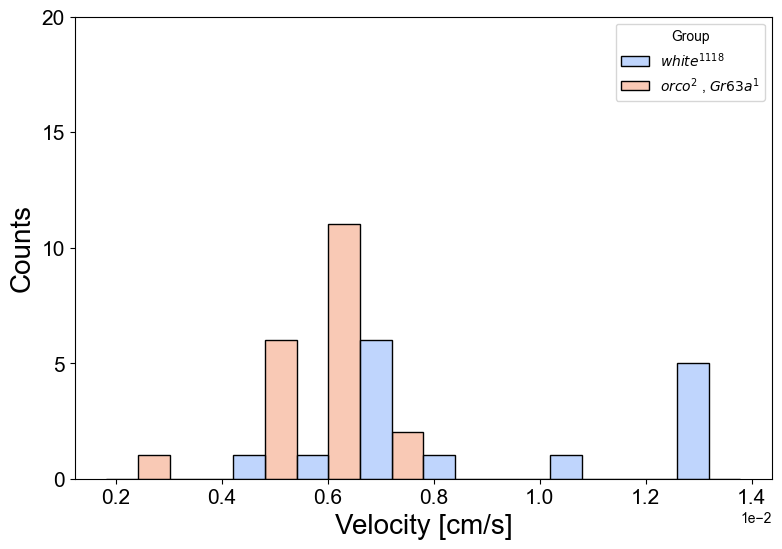

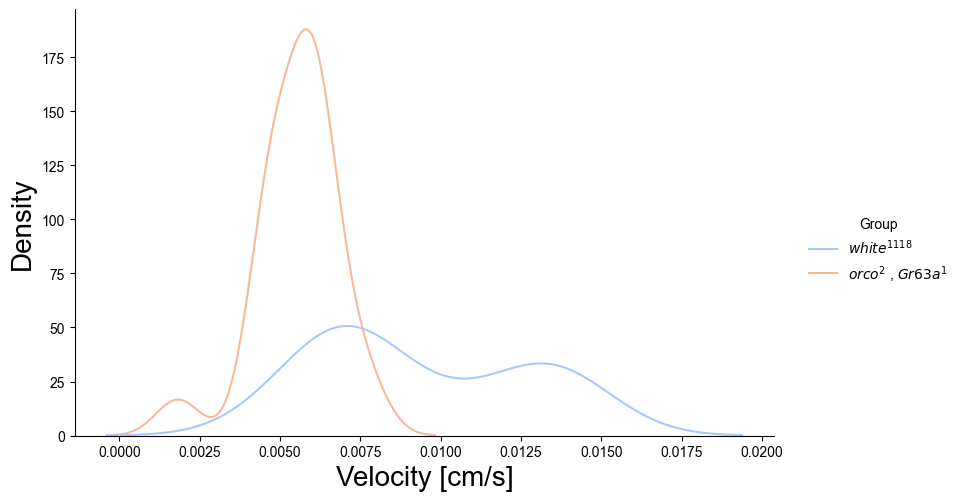

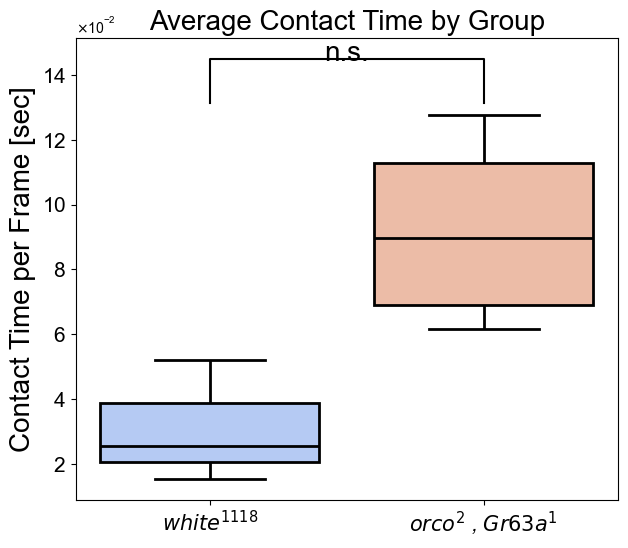

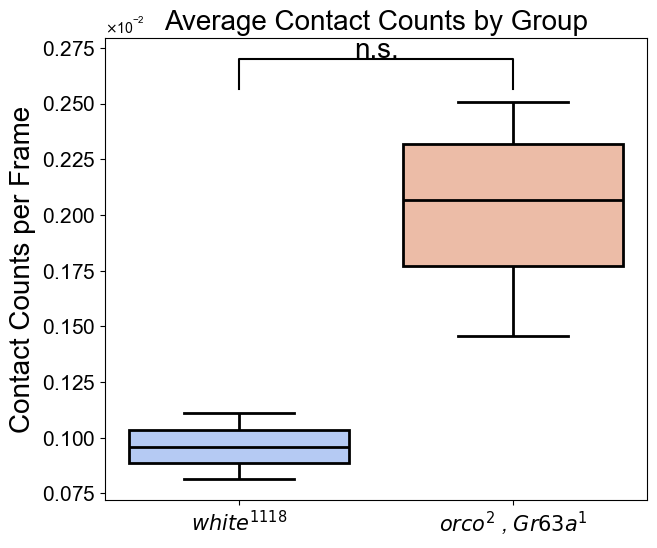

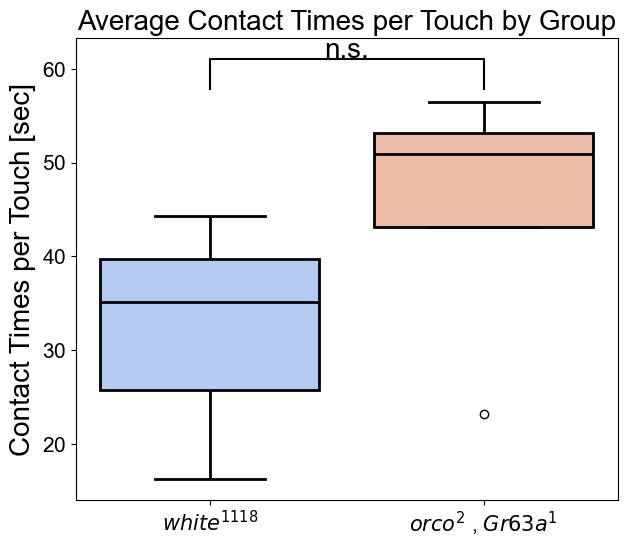

In [50]:
PIXEL_TO_CM = 0.006
Thr_frame = 2000

date = '20250127+overfit'
Head_radius = 25
max_gap = 10
max_displacement = 5
angle_threshold = 35
speed_threshold = 0.3
frame_interval = 5

filename = f"{date}_thrframe{Thr_frame}_radius{Head_radius}_maxgap{max_gap}_maxdisplacement{max_displacement}_anglethr{angle_threshold}_speedthr{speed_threshold}_frameinterval{frame_interval}"

os.makedirs(f"./Fig_paper/{filename}/", exist_ok=True)


results_combine, results_df, results_df_d = distance_compute(
    PIXEL_TO_CM=PIXEL_TO_CM
)
plot_distance_compare(results_combine, results_df, results_df_d, filename=filename)
## Contactの確認
start_now = datetime.now(pytz.timezone("Asia/Tokyo"))
print(
    "Checking contacts...{}".format(start_now.strftime("%Y-%m-%d %H:%M:%S")),
    flush=True,
)
control_matrix_files, mutant_matrix_files = select_frames_of_contact_events(
    thr_frame=Thr_frame
)
contact_time_rate_df = summarize_contacts_time_controls_and_mutants(
    control_matrix_files, mutant_matrix_files
)
plot_contact_time_rate_compare(contact_time_rate_df, filename=filename)
contact_count_rate_df = summarize_contacts_count_controls_and_mutants(
    control_matrix_files, mutant_matrix_files
)
plot_contact_count_compare(contact_count_rate_df, filename=filename)
contact_time_per_touch_df = summarize_contacts_time_per_touch_controls_and_mutants(
    control_matrix_files, mutant_matrix_files
)


plot_contact_time_per_touch_compare(contact_time_per_touch_df, filename=filename)


In [33]:
control_rates

0    0.051956
1    0.015336
Name: Contact_time_rate, dtype: float64

In [4]:
control_matrix_files + mutant_matrix_files

['./csvs/trajectory/C1_L5_ori_overfit.csv',
 './csvs/trajectory/C2_L5_ori_overfit.csv',
 './csvs/trajectory/C3-1_L5_ori_overfit.csv',
 './csvs/trajectory/D2_L5_ori_overfit.csv',
 './csvs/trajectory/D3-1_L5_ori_overfit.csv',
 './csvs/trajectory/D3-2_L4_ori_overfit.csv',
 './csvs/trajectory/D4-1_L5_ori_overfit.csv',
 './csvs/trajectory/D5-1_L5_ori_overfit.csv']

In [10]:
def correct_flip(angles, flip_threshold=np.deg2rad(150)):
    """
    angles: 各フレームごとの体軸の向き（ラジアン）
    flip_threshold: もし前フレームとの角度差がこの閾値（ラジアン）より大きければ、
                    head-tail の flip（180°近いジャンプ）とみなして補正する。
    """
    corrected = angles.copy()
    for i in range(1, len(corrected)):
        diff = corrected[i] - corrected[i-1]
        # もし急激な変化があれば、flip と判断して π（180°）を補正する
        if abs(diff) > flip_threshold:
            corrected[i] -= np.sign(diff) * np.pi
    return corrected

# --- 2. 連続した転回イベントを検出する関数 ---
def detect_gradual_turns(angles, frames, threshold_deg=90, min_duration_frames=3):
    """
    angles: 補正・unwrap 済みの体軸向き（ラジアン）の時系列データ
    frames: 対応するフレーム番号の配列（例：[4,5,6,7,…]）
    threshold_deg: 累積角度がこれ以上（°）変化した場合に転回とみなす
    min_duration_frames: 転回イベントとしてカウントするための最低継続フレーム数

    Returns:
        転回イベントのリスト（各イベントは dict で、開始フレーム・終了フレーム・累積角度などを記録）
    """
    segments = []
    if len(angles) < 2:
        return segments

    start_idx = 0
    cumulative_angle = 0.0  # セグメント内での累積角度（ラジアン）
    for i in range(1, len(angles)):
        dtheta = angles[i] - angles[i-1]
        # セグメント開始直後は dtheta で累積を初期化
        if i == start_idx + 1:
            cumulative_angle = dtheta
        else:
            # dtheta の符号がこれまでの累積と同じなら加算
            if np.sign(dtheta) == np.sign(cumulative_angle) or cumulative_angle == 0:
                cumulative_angle += dtheta
            else:
                # 符号が変わった＝転回イベントが一区切りしたとみなす
                duration = frames[i-1] - frames[start_idx] + 1
                if duration >= min_duration_frames and abs(np.degrees(cumulative_angle)) >= threshold_deg:
                    segments.append({
                        'start_frame': frames[start_idx],
                        'end_frame': frames[i-1],
                        'duration': duration,
                        'cumulative_turn_deg': np.degrees(cumulative_angle)
                    })
                # 新しいセグメントの開始
                start_idx = i-1
                cumulative_angle = dtheta
    # 最後のセグメントのチェック
    duration = frames[-1] - frames[start_idx] + 1
    if duration >= min_duration_frames and abs(np.degrees(cumulative_angle)) >= threshold_deg:
        segments.append({
            'start_frame': frames[start_idx],
            'end_frame': frames[-1],
            'duration': duration,
            'cumulative_turn_deg': np.degrees(cumulative_angle)
        })
    return segments

In [74]:
import csv
import math
import statistics
from collections import defaultdict

# ----- 1. 各フレームの曲がり（curvature）を計算する関数 -----
def compute_body_angle(head, middle, tail):
    """
    Head, Middle, Tail が (x, y) のタプルで与えられた場合、
    Middle における角度（Head-Middle と Tail-Middle のなす角）を返す。
    体が一直線なら約 π、曲がっていればこの値は小さくなる。
    """
    v1 = (head[0] - middle[0], head[1] - middle[1])
    v2 = (tail[0] - middle[0], tail[1] - middle[1])
    norm1 = math.hypot(v1[0], v1[1])
    norm2 = math.hypot(v2[0], v2[1])
    if norm1 == 0 or norm2 == 0:
        return None  # 異常値対策
    dot = v1[0]*v2[0] + v1[1]*v2[1]
    cos_angle = max(min(dot / (norm1 * norm2), 1.0), -1.0)
    angle = math.acos(cos_angle)
    return angle

# ----- 2. 局所最小判定の補助関数 -----
def is_local_minimum(curvatures, idx, window=2):
    """
    curvatures: 各フレームの curvature のリスト
    idx: 判定対象のインデックス
    window: 前後何フレームと比較するか（例：window=2なら idx-2～idx+2内で比較）
    
    → idx の値が、指定窓内で最も低い（最小値）なら True を返す
    """
    current = curvatures[idx]
    for i in range(max(0, idx - window), min(len(curvatures), idx + window + 1)):
        if i == idx:
            continue
        if curvatures[i] is None or current is None:
            continue
        if current > curvatures[i]:
            return False
    return True

# ----- 3. データ読み込み＆グループ化（ID毎） -----
data_by_id = defaultdict(list)
input_filename = mutant_matrix_files[0]  # 入力ファイル（例: CSV, 区切り文字はカンマ）
with open(input_filename, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=',')
    for row in reader:
        frame = int(row['Frame'])
        id_val = row['ID']  # 必要に応じ int(row['ID']) に変換
        head = (float(row['Head_X']), float(row['Head_Y']))
        middle = (float(row['Middle_X']), float(row['Middle_Y']))
        tail = (float(row['Tail_X']), float(row['Tail_Y']))
        data_by_id[id_val].append({
            'Frame': frame,
            'Head': head,
            'Middle': middle,
            'Tail': tail
            # 後で 'Curvature' と 'KuShape' を追加
        })

# ----- 4. 各個体ごとにフレーム順に処理：curvature計算とくの字判定 -----
# パラメータ設定
curvature_threshold = 2.5    # 例: 2.5 rad 未満なら十分に曲がっているとみなす
local_window = 0       # 前後2フレームと比較

for id_val, frames in data_by_id.items():
    frames.sort(key=lambda x: x['Frame'])
    curvatures = []
    for frame_data in frames:
        head = frame_data['Head']
        middle = frame_data['Middle']
        tail = frame_data['Tail']
        curvature = compute_body_angle(head, middle, tail)
        frame_data['Curvature'] = curvature  # 新カラムとして追加
        curvatures.append(curvature)
    
    # 各フレームが「くの字状態」かどうかの判定
    for i, frame_data in enumerate(frames):
        curvature = frame_data['Curvature']
        if curvature is None:
            frame_data['KuShape'] = False
        else:
            # 単純に閾値以下かつ、局所的な最小値なら True
            frame_data['KuShape'] = (curvature < curvature_threshold and 
                                      is_local_minimum(curvatures, i, window=local_window))

# ----- 5. 連続する「くの字状態」フレームをイベントとして抽出（連続フレーム数が十分な場合のみ） -----
min_event_length = 15  # 例: 3フレーム以上連続していなければイベントとしない
events_by_id = {}
for id_val, frames in data_by_id.items():
    events = []
    current_event = []  # 現在のイベントに属するフレーム番号のリスト
    for frame_data in frames:
        if frame_data['KuShape']:
            current_event.append(frame_data['Frame'])
        else:
            if len(current_event) >= min_event_length:
                events.append(current_event)
            current_event = []
    if len(current_event) >= min_event_length:
        events.append(current_event)
    events_by_id[id_val] = events

# ----- 6. 結果の表示 -----
for id_val, events in events_by_id.items():
    print(f"ID: {id_val}")
    if events:
        for event in events:
            print(f"  くの字イベント（連続フレーム）From {event[0]} : {event[-1]}")
    else:
        print("  くの字イベントは検出されませんでした。")


ID: 1
  くの字イベント（連続フレーム）From 20 : 109
  くの字イベント（連続フレーム）From 112 : 150
  くの字イベント（連続フレーム）From 154 : 176
  くの字イベント（連続フレーム）From 197 : 307
  くの字イベント（連続フレーム）From 553 : 610
  くの字イベント（連続フレーム）From 710 : 803
  くの字イベント（連続フレーム）From 824 : 919
  くの字イベント（連続フレーム）From 1093 : 1128
  くの字イベント（連続フレーム）From 1144 : 1188
  くの字イベント（連続フレーム）From 1192 : 1234
  くの字イベント（連続フレーム）From 1245 : 1294
  くの字イベント（連続フレーム）From 1345 : 1414
  くの字イベント（連続フレーム）From 1429 : 1475
  くの字イベント（連続フレーム）From 1592 : 1621
  くの字イベント（連続フレーム）From 1674 : 1697
  くの字イベント（連続フレーム）From 1723 : 1744
  くの字イベント（連続フレーム）From 1801 : 1875
  くの字イベント（連続フレーム）From 2119 : 2134
  くの字イベント（連続フレーム）From 2163 : 2194
  くの字イベント（連続フレーム）From 2249 : 2267
  くの字イベント（連続フレーム）From 2277 : 2329
  くの字イベント（連続フレーム）From 2458 : 2482
  くの字イベント（連続フレーム）From 2724 : 2746
  くの字イベント（連続フレーム）From 2922 : 2999
ID: 2
  くの字イベント（連続フレーム）From 42 : 61
  くの字イベント（連続フレーム）From 121 : 162
  くの字イベント（連続フレーム）From 243 : 273
  くの字イベント（連続フレーム）From 319 : 369
  くの字イベント（連続フレーム）From 419 : 434
  くの字イベント（連続フレーム）From 647 : 7

In [73]:
len(events)

12

In [78]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import glob
import re
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm
from natsort import natsorted
from scipy.spatial.distance import euclidean
from scipy import stats
from pykalman import KalmanFilter
from scipy.interpolate import UnivariateSpline
from sklearn.ensemble import IsolationForest

# --- matplotlib のフォント設定 ---
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'

# =============================================================================
# 【ファイル選択用関数】
# =============================================================================
def select_frames(thr_frame=5000):
    control_matrix_files = []
    for path in natsorted(glob.glob('./csvs/trajectory/C*')):
        print(f"Selecting frames from {path}")
        tmp_df = pd.read_csv(path)
        total_frames = tmp_df['Frame'].max() + 1
        if total_frames > thr_frame:
            print(path)
            control_matrix_files.append(path)

    mutant_matrix_files = []
    for path in natsorted(glob.glob('./csvs/trajectory/D*')):
        print(f"Selecting frames from {path}")
        tmp_df = pd.read_csv(path)
        total_frames = tmp_df['Frame'].max() + 1
        if total_frames > thr_frame:
            print(path)
            mutant_matrix_files.append(path)
            
    return control_matrix_files, mutant_matrix_files

def selected_frames(thr_frame=5000):
    control_matrix_files = []
    for path in natsorted(glob.glob('./csvs/selected_trajectory/C*')):
        print(f"Selecting frames from {path}")
        tmp_df = pd.read_csv(path)
        total_frames = tmp_df['Frame'].max() + 1
        if total_frames > thr_frame:
            print(path)
            control_matrix_files.append(path)

    mutant_matrix_files = []
    for path in natsorted(glob.glob('./csvs/selected_trajectory/D*')):
        print(f"Selecting frames from {path}")
        tmp_df = pd.read_csv(path)
        total_frames = tmp_df['Frame'].max() + 1
        if total_frames > thr_frame:
            print(path)
            mutant_matrix_files.append(path)
            
    return control_matrix_files, mutant_matrix_files

# =============================================================================
# 【トラジェクトリ前処理：カルマンフィルタ・スプライン補間・IDスワップ修正・角度補正】
# =============================================================================
def create_kalman_filter(x, y):
    kf = KalmanFilter(initial_state_mean=[x, y, 0, 0],
                      transition_matrices=[[1, 0, 1, 0],
                                           [0, 1, 0, 1],
                                           [0, 0, 1, 0],
                                           [0, 0, 0, 1]],
                      observation_matrices=[[1, 0, 0, 0],
                                            [0, 1, 0, 0]],
                      transition_covariance=0.01 * np.eye(4),
                      observation_covariance=10.0 * np.eye(2),
                      initial_state_covariance=100.0 * np.eye(4))
    return kf

def smooth_trajectory(data):
    data = data.copy()
    ids = data['ID'].unique()
    smoothed_data = []
    for id_value in tqdm(ids, desc="Smoothing Trajectories"):
        id_data = data[data['ID'] == id_value].sort_values(by='Frame')
        frames = id_data['Frame'].values
        # Middle 座標を対象に線形補間
        df_interp = id_data[['Middle_X', 'Middle_Y']].interpolate(method='linear', limit_direction='both')
        observations = df_interp.values
        if observations.ndim != 2 or observations.shape[1] != 2:
            print(f"ID {id_value} の観測データの形状が不正です。スキップします。")
            continue
        kf = create_kalman_filter(observations[0, 0], observations[0, 1])
        state_means, _ = kf.smooth(observations)
        m = len(frames)
        k = 3
        if m <= k:
            k = m - 1 if m > 1 else 0
            if k >= 1:
                smoothed_x = UnivariateSpline(frames, state_means[:, 0], k=k, s=0)(frames)
                smoothed_y = UnivariateSpline(frames, state_means[:, 1], k=k, s=0)(frames)
            else:
                smoothed_x = state_means[:, 0]
                smoothed_y = state_means[:, 1]
        else:
            smoothed_x = UnivariateSpline(frames, state_means[:, 0], s=2)(frames)
            smoothed_y = UnivariateSpline(frames, state_means[:, 1], s=2)(frames)
        id_data['Smoothed_X'] = smoothed_x
        id_data['Smoothed_Y'] = smoothed_y
        smoothed_data.append(id_data)
    return pd.concat(smoothed_data).reset_index(drop=True)

def detect_id_swaps(data, max_displacement=20):
    data = data.copy()
    ids = data['ID'].unique()
    swap_frames = []
    for id_value in tqdm(ids, desc="Detecting ID Swaps"):
        id_data = data[data['ID'] == id_value].sort_values(by='Frame')
        positions = id_data[['Smoothed_X', 'Smoothed_Y']].values
        displacements = np.linalg.norm(np.diff(positions, axis=0), axis=1)
        abnormal_indices = np.where(displacements > max_displacement)[0] + 1
        swap_frames.extend(id_data.iloc[abnormal_indices]['Frame'].tolist())
    for frame in swap_frames:
        current_data = data[data['Frame'] == frame]
        previous_data = data[data['Frame'] == frame - 1]
        for id_value in ids:
            curr_row = current_data[current_data['ID'] == id_value]
            prev_row = previous_data[previous_data['ID'] == id_value]
            if curr_row.empty or prev_row.empty:
                continue
            displacement = np.linalg.norm([
                curr_row['Smoothed_X'].values[0] - prev_row['Smoothed_X'].values[0],
                curr_row['Smoothed_Y'].values[0] - prev_row['Smoothed_Y'].values[0]
            ])
            if displacement > max_displacement:
                for other_id in ids:
                    if other_id == id_value:
                        continue
                    other_prev_row = previous_data[previous_data['ID'] == other_id]
                    if other_prev_row.empty:
                        continue
                    other_displacement = np.linalg.norm([
                        curr_row['Smoothed_X'].values[0] - other_prev_row['Smoothed_X'].values[0],
                        curr_row['Smoothed_Y'].values[0] - other_prev_row['Smoothed_Y'].values[0]
                    ])
                    if other_displacement < displacement:
                        data.loc[(data['Frame'] == frame) & (data['ID'] == id_value), 'ID'] = other_id
                        data.loc[(data['Frame'] == frame) & (data['ID'] == other_id), 'ID'] = id_value
                        break
    return data.sort_values(by=['Frame', 'ID']).reset_index(drop=True)

def calculate_angle_between_vectors(T, m, H):
    T_mg = m - T
    mg_H = H - m
    dot_product = np.dot(T_mg, mg_H)
    magnitude_T_mg = np.linalg.norm(T_mg)
    magnitude_mg_H = np.linalg.norm(mg_H)
    if magnitude_T_mg == 0 or magnitude_mg_H == 0:
        return np.nan
    cos_theta = dot_product / (magnitude_T_mg * magnitude_mg_H)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    theta_degrees = np.degrees(theta)
    return theta_degrees

def correct_angles_per_id(data, threshold=45, accept_threshold=35):
    def correct_angles(group):
        valid_indices = []
        corrected_angles = []
        Tail_x = []
        Tail_y = []
        Head_x = []
        Head_y = []
        group_Tail_x = group['Tail_X'].values.copy()
        group_Tail_y = group['Tail_Y'].values.copy()
        group_Mid_x = group['Middle_X'].values
        group_Mid_y = group['Middle_Y'].values
        group_Head_x = group['Head_X'].values.copy()
        group_Head_y = group['Head_Y'].values.copy()
        for i in range(len(group)):
            T = np.array([group_Tail_x[i], group_Tail_y[i]])
            m = np.array([group_Mid_x[i], group_Mid_y[i]])
            H = np.array([group_Head_x[i], group_Head_y[i]])
            angle = calculate_angle_between_vectors(T, m, H)
            if i > 0 and len(corrected_angles) > 0:
                prev_angle = corrected_angles[-1]
                delta = abs(angle - prev_angle)
                if delta > threshold:
                    T_swapped = np.array([group_Head_x[i], group_Head_y[i]])
                    H_swapped = np.array([group_Tail_x[i], group_Tail_y[i]])
                    angle_swapped = calculate_angle_between_vectors(T_swapped, m, H_swapped)
                    delta_swapped = abs(angle_swapped - prev_angle)
                    if delta_swapped < accept_threshold:
                        Tail_x.append(T_swapped[0])
                        Tail_y.append(T_swapped[1])
                        Head_x.append(H_swapped[0])
                        Head_y.append(H_swapped[1])
                        corrected_angles.append(angle_swapped)
                        valid_indices.append(group.index[i])
                    else:
                        continue
                else:
                    Tail_x.append(T[0])
                    Tail_y.append(T[1])
                    Head_x.append(H[0])
                    Head_y.append(H[1])
                    corrected_angles.append(angle)
                    valid_indices.append(group.index[i])
            else:
                Tail_x.append(T[0])
                Tail_y.append(T[1])
                Head_x.append(H[0])
                Head_y.append(H[1])
                corrected_angles.append(angle)
                valid_indices.append(group.index[i])
        corrected_group = group.loc[valid_indices].copy()
        corrected_group['Tail_X'] = Tail_x
        corrected_group['Tail_Y'] = Tail_y
        corrected_group['Head_X'] = Head_x
        corrected_group['Head_Y'] = Head_y
        corrected_group['Corrected_Angle'] = corrected_angles
        return corrected_group
    corrected_data = data.groupby('ID', group_keys=False).apply(correct_angles)
    return corrected_data

# =============================================================================
# 【接触イベント検出・集計・可視化】
# =============================================================================
def group_consecutive_frames(frames_list, max_gap=1):
    grouped_frames = []
    frames_list = sorted(frames_list)
    group = [frames_list[0]]
    for i in range(1, len(frames_list)):
        if frames_list[i] - frames_list[i - 1] <= max_gap + 1:
            group.append(frames_list[i])
        else:
            grouped_frames.append(group)
            group = [frames_list[i]]
    grouped_frames.append(group)
    return grouped_frames

def detect_contact_events_with_direction(data, head_radius, max_gap):
    data = data.copy()
    frames = data['Frame'].unique()
    ids = data['ID'].unique()
    contact_dict = {}
    for frame in tqdm(frames, desc='Detecting Contacts with Direction'):
        frame_data = data[data['Frame'] == frame]
        for i in range(len(frame_data)):
            id1 = frame_data.iloc[i]['ID']
            head_x1 = frame_data.iloc[i]['Head_X']
            head_y1 = frame_data.iloc[i]['Head_Y']
            head_pos1 = np.array([head_x1, head_y1])
            for j in range(len(frame_data)):
                if i == j:
                    continue
                id2 = frame_data.iloc[j]['ID']
                tail_pos2 = np.array([frame_data.iloc[j]['Tail_X'], frame_data.iloc[j]['Tail_Y']])
                middle_pos2 = np.array([frame_data.iloc[j]['Middle_X'], frame_data.iloc[j]['Middle_Y']])
                head_pos2 = np.array([frame_data.iloc[j]['Head_X'], frame_data.iloc[j]['Head_Y']])
                distances = [
                    np.linalg.norm(head_pos1 - tail_pos2),
                    np.linalg.norm(head_pos1 - middle_pos2),
                    np.linalg.norm(head_pos1 - head_pos2)
                ]
                min_distance = min(distances)
                if min_distance <= head_radius:
                    key = (id1, id2)
                    if key in contact_dict:
                        contact_dict[key].append(frame)
                    else:
                        contact_dict[key] = [frame]
    contact_events = []
    for pair, frames_list in contact_dict.items():
        grouped_frames = group_consecutive_frames(frames_list, max_gap)
        for group in grouped_frames:
            start_frame = group[0]
            end_frame = group[-1]
            event = {
                'id1': pair[0],
                'id2': pair[1],
                'start_frame': start_frame,
                'end_frame': end_frame
            }
            contact_events.append(event)
    contact_events_df = pd.DataFrame(contact_events, columns=['id1', 'id2', 'start_frame', 'end_frame'])
    return contact_events_df

def summarize_interactions(contact_events_df):
    contact_events_df = contact_events_df.copy()
    contact_events_df['duration'] = contact_events_df['end_frame'] - contact_events_df['start_frame'] + 1
    ids = pd.unique(contact_events_df[['id1', 'id2']].values.ravel('K'))
    from natsort import natsorted
    interaction_matrix = pd.DataFrame(0, index=natsorted(ids), columns=natsorted(ids))
    for _, row in contact_events_df.iterrows():
        id1 = row['id1']
        id2 = row['id2']
        duration = row['duration']
        interaction_matrix.loc[id1, id2] += duration
    total_interactions = interaction_matrix.sum(axis=1)
    interaction_ratio = interaction_matrix.div(total_interactions, axis=0).fillna(0)
    return interaction_matrix, interaction_ratio

def plot_interaction_heatmap(interaction_matrix, title="Interaction Time Heatmap"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(interaction_matrix, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title(title)
    plt.xlabel("ID")
    plt.ylabel("ID")
    plt.show()

def plot_interaction_network(interaction_matrix, threshold=0):
    G = nx.Graph()
    for node in interaction_matrix.index:
        G.add_node(node)
    for i in interaction_matrix.index:
        for j in interaction_matrix.columns:
            if i < j:
                weight = interaction_matrix.loc[i, j]
                if weight > threshold:
                    G.add_edge(i, j, weight=weight)
    pos = nx.circular_layout(G)
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    max_weight = max(weights) if weights else 1
    widths = [weight / max_weight * 5 for weight in weights]
    node_weights = interaction_matrix.sum(axis=1)
    max_node_weight = max(node_weights) if not node_weights.empty else 1
    node_sizes = [node_weights[node] / max_node_weight * 5000 for node in G.nodes()]
    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue')
    nx.draw_networkx_labels(G, pos)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color='gray')
    plt.title("Interaction Network Graph")
    plt.axis('off')
    plt.show()

def plot_contact_count_heatmap(contact_events_df):
    contact_counts = contact_events_df.groupby(['id1', 'id2']).size().reset_index(name='Contact_Count')
    ids = sorted(set(contact_counts['id1']).union(set(contact_counts['id2'])))
    interaction_matrix = pd.DataFrame(0, index=ids, columns=ids)
    for _, row in contact_counts.iterrows():
        id_from = row['id1']
        id_to = row['id2']
        count = row['Contact_Count']
        interaction_matrix.loc[id_from, id_to] = count
    plt.figure(figsize=(10, 8))
    sns.heatmap(interaction_matrix, annot=True, fmt=".0f", cmap="YlGnBu", mask=interaction_matrix.isnull())
    plt.title("Directional Contact Counts Heatmap (Upper Triangular)")
    plt.xlabel("ID To")
    plt.ylabel("ID From")
    plt.show()

def process_contact_events(data, head_radius=5.0, max_gap=1, max_displacement=20):
    data = data.copy()
    data = data.sort_values(by=['Frame', 'ID']).reset_index(drop=True)
    data = correct_angles_per_id(data)
    data = smooth_trajectory(data)
    data = detect_id_swaps(data, max_displacement=max_displacement)
    contact_events = detect_contact_events_with_direction(data, head_radius, max_gap)
    return contact_events

# =============================================================================
# 【回転（くの字）イベント検出・集計・可視化】
# =============================================================================
def compute_body_angle_for_rotation(head, middle, tail):
    v1 = (head[0] - middle[0], head[1] - middle[1])
    v2 = (tail[0] - middle[0], tail[1] - middle[1])
    norm1 = math.hypot(v1[0], v1[1])
    norm2 = math.hypot(v2[0], v2[1])
    if norm1 == 0 or norm2 == 0:
        return np.nan
    dot = v1[0]*v2[0] + v1[1]*v2[1]
    cos_angle = max(min(dot / (norm1 * norm2), 1.0), -1.0)
    angle = math.acos(cos_angle)
    return angle

def detect_rotation_events_with_direction(data, min_event_length=15, curvature_threshold=2.5, local_window=0, max_gap=1):
    data = data.copy()
    def compute_curv_row(row):
        head = (row['Head_X'], row['Head_Y'])
        middle = (row['Middle_X'], row['Middle_Y'])
        tail = (row['Tail_X'], row['Tail_Y'])
        return compute_body_angle_for_rotation(head, middle, tail)
    data['Curvature'] = data.apply(compute_curv_row, axis=1)
    def compute_ku_shape(group):
        group = group.sort_values('Frame').copy()
        curvatures = group['Curvature'].tolist()
        ku_shape_flags = []
        for i, curv in enumerate(curvatures):
            if curv is None or np.isnan(curv):
                ku_shape_flags.append(False)
            else:
                flag = (curv < curvature_threshold and is_local_minimum(curvatures, i, window=local_window))
                ku_shape_flags.append(flag)
        group['KuShape'] = ku_shape_flags
        return group
    data = data.groupby('ID', group_keys=False).apply(compute_ku_shape)
    events = []
    for id_val, group in data.groupby('ID'):
        group = group.sort_values('Frame')
        frames_true = group.loc[group['KuShape'], 'Frame'].tolist()
        groups = group_consecutive_frames(frames_true, max_gap=max_gap)
        for g in groups:
            if len(g) >= min_event_length:
                event = {
                    'ID': id_val,
                    'start_frame': g[0],
                    'end_frame': g[-1],
                    'duration': g[-1] - g[0] + 1,
                    'event_frames': g
                }
                events.append(event)
    rotation_events_df = pd.DataFrame(events)
    return rotation_events_df

def summarize_rotation_events(rotation_events_df):
    if rotation_events_df.empty:
        return pd.DataFrame()
    summary_df = rotation_events_df.groupby('ID').agg(
        event_count=('ID', 'count'),
        total_duration=('duration', 'sum'),
        mean_duration=('duration', 'mean'),
        median_duration=('duration', 'median')
    ).reset_index()
    return summary_df

def plot_rotation_event_boxplot(rotation_events_df):
    if rotation_events_df.empty:
        print("回転イベントが検出されませんでした。")
        return
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='ID', y='duration', data=rotation_events_df)
    plt.title("Rotation Event Durations by ID")
    plt.xlabel("ID")
    plt.ylabel("Duration (frames)")
    plt.show()

def plot_rotation_event_scatter(summary_df):
    if summary_df.empty:
        print("サマリー情報がありません。")
        return
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='event_count', y='mean_duration', hue='ID', data=summary_df, s=100)
    plt.title("Rotation Event Count vs Mean Duration")
    plt.xlabel("Event Count")
    plt.ylabel("Mean Duration (frames)")
    plt.legend(title='ID')
    plt.show()

# =============================================================================
# 【距離計算・可視化】
# =============================================================================
def calculate_distances(df, PIXEL_TO_CM=0.006):
    distances = {track_id: 0 for track_id in df["ID"].unique()}
    total_frame_counts = {track_id: 0 for track_id in df["ID"].unique()}
    for track_id in df["ID"].unique():
        track_data = df[df["ID"] == track_id].sort_values("Frame")
        previous_position = None
        previous_frame = None
        frames = track_data["Frame"].values
        if len(frames) == 0:
            continue
        first_frame = frames[0]
        last_frame = frames[-1]
        total_frames = last_frame - first_frame + 1
        total_frame_counts[track_id] = total_frames
        for idx, row in track_data.iterrows():
            current_position = (row["Middle_X"], row["Middle_Y"])
            current_frame = row["Frame"]
            if previous_position is not None:
                frame_diff = current_frame - previous_frame
                if frame_diff > 0:
                    distance = euclidean(previous_position, current_position) * PIXEL_TO_CM
                    distances[track_id] += distance
            previous_position = current_position
            previous_frame = current_frame
    return distances, total_frame_counts

def distance_compute(PIXEL_TO_CM=0.006):
    results = []
    for path in natsorted(glob.glob("./csvs/interaction_matrcies/contact_events_C*")):
        filename = os.path.splitext(os.path.basename(path))[0][15:]
        df = pd.read_csv("./csvs/trajectory/{}.csv".format(filename))
        distances, frame_counts = calculate_distances(df, PIXEL_TO_CM)
        print(path)
        print("Total distances traveled by each track ID:")
        for track_id in distances.keys():
            distance = distances[track_id]
            frame_count = frame_counts[track_id]
            avg_distance = distance / frame_count if frame_count > 0 else 0
            results.append([os.path.basename(path), track_id, distance, avg_distance, "$white^{1118}$"])
            print(f"Track ID {track_id}: Total Distance = {distance:.2f} cm, Frames = {frame_count}, Avg Distance = {avg_distance:.4f} cm/frame")
        print("")
    results_df = pd.DataFrame(results, columns=["path", "track_id", "distance", "avg_distance", "Group"])
    results_d = []
    for path in natsorted(glob.glob("./csvs/interaction_matrcies/contact_events_D*")):
        filename = os.path.splitext(os.path.basename(path))[0][15:]
        df = pd.read_csv("./csvs/trajectory/{}.csv".format(filename))
        distances, frame_counts = calculate_distances(df, PIXEL_TO_CM)
        print(path)
        print("Total distances traveled by each track ID:")
        for track_id in distances.keys():
            distance = distances[track_id]
            frame_count = frame_counts[track_id]
            avg_distance = distance / frame_count if frame_count > 0 else 0
            results_d.append([os.path.basename(path), track_id, distance, avg_distance, "$orco^2$ , $Gr63a^1$"])
            print(f"Track ID {track_id}: Total Distance = {distance:.2f} cm, Frames = {frame_count}, Avg Distance = {avg_distance:.4f} cm/frame")
        print("")
    results_df_d = pd.DataFrame(results_d, columns=["path", "track_id", "distance", "avg_distance", "Group"])
    results_combine = pd.concat([results_df, results_df_d])
    return results_combine, results_df, results_df_d

def plot_distance_compare(results_combine, results_df, results_df_d, filename=None):
    mutant = results_df_d["avg_distance"]
    control = results_df["avg_distance"]
    ks_stat, ks_p_value = stats.ks_2samp(control, mutant)
    print("KS検定:")
    print(f"統計量 = {ks_stat}, p値 = {ks_p_value}\n")
    mw_stat, mw_p_value = stats.mannwhitneyu(control, mutant, alternative="two-sided")
    print("マン・ホイットニーU検定:")
    print(f"統計量 = {mw_stat}, p値 = {mw_p_value}\n")
    kw_stat, kw_p_value = stats.kruskal(control, mutant)
    print("クラスカル・ウォリス検定:")
    print(f"統計量 = {kw_stat}, p値 = {kw_p_value}")
    fig, ax = plt.subplots(figsize=(9, 6))
    results_combine = pd.concat([results_df, results_df_d])
    sns.histplot(data=results_combine, x="avg_distance", hue="Group", palette="coolwarm", multiple="dodge")
    plt.xlabel("Velocity [cm/s]", fontsize=20)
    plt.yticks(np.arange(0, 24, 5))
    plt.ylabel("Counts", fontsize=20)
    ax.ticklabel_format(style="sci", axis="x", scilimits=(-2, -2))
    ax.tick_params(axis="y", labelsize=15)
    ax.tick_params(axis="x", labelsize=15)
    if filename:
        out_path = f"./Fig_paper/{filename}/velocity_compare_{filename}.pdf"
        plt.savefig(out_path)
        print(f"PDF saved at {out_path}")
    sns.displot(data=results_combine, x="avg_distance", hue="Group", palette="coolwarm", kind="kde", height=5, aspect=1.6)
    plt.xlabel("Velocity [cm/s]", fontsize=20)
    plt.ylabel("Density", fontsize=20)
    ax.ticklabel_format(style="sci", axis="x", scilimits=(-2, -2))
    ax.tick_params(axis="y", labelsize=15)
    ax.tick_params(axis="x", labelsize=15)
    if filename:
        out_path = f"./Fig_paper/{filename}/contact_time_compare_density_all_{filename}.pdf"
        plt.savefig(out_path)
        print(f"PDF saved at {out_path}")

# =============================================================================
# 【新規追加：グループ別結果プロット関数】
# =============================================================================
def plot_interaction_results_by_group(control_matrix_files, mutant_matrix_files, 
                                      head_radius=15, max_gap=5, max_displacement=20):
    """
    control_matrix_files と mutant_matrix_files のそれぞれの結果（接触イベント）を処理し、
    グループごとにインタラクションのヒートマップおよび接触イベント持続時間のボックスプロットを描画する。
    """
    # --- コントロール群 ---
    control_events_list = []
    for path in tqdm(control_matrix_files, desc="Processing Controls"):
        traj_csv = pd.read_csv(path)
        events_df = process_contact_events(traj_csv, head_radius=head_radius, max_gap=max_gap, max_displacement=max_displacement)
        control_events_list.append(events_df)
    if control_events_list:
        control_events = pd.concat(control_events_list, ignore_index=True)
    else:
        control_events = pd.DataFrame()
    
    # --- ミュータント群 ---
    mutant_events_list = []
    for path in tqdm(mutant_matrix_files, desc="Processing Mutants"):
        traj_csv = pd.read_csv(path)
        events_df = process_contact_events(traj_csv, head_radius=head_radius, max_gap=max_gap, max_displacement=max_displacement)
        mutant_events_list.append(events_df)
    if mutant_events_list:
        mutant_events = pd.concat(mutant_events_list, ignore_index=True)
    else:
        mutant_events = pd.DataFrame()
    
    # 集計：各グループのインタラクションマトリックス
    control_matrix, _ = summarize_interactions(control_events)
    mutant_matrix, _ = summarize_interactions(mutant_events)
    
    # プロット：各群のヒートマップ
    plot_interaction_heatmap(control_matrix, title="Control Group Interaction Time Heatmap")
    plot_interaction_heatmap(mutant_matrix, title="Mutant Group Interaction Time Heatmap")
    
    # もし接触イベントの持続時間（duration）を比較する場合はボックスプロットで可視化
    if not control_events.empty:
        control_events['Group'] = 'Control'
    if not mutant_events.empty:
        mutant_events['Group'] = 'Mutant'
    combined_events = pd.concat([control_events, mutant_events], ignore_index=True)
    if not combined_events.empty and 'duration' in combined_events.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Group', y='duration', data=combined_events)
        plt.title("Contact Event Durations by Group")
        plt.xlabel("Group")
        plt.ylabel("Duration (frames)")
        plt.show()



Selecting frames from ./csvs/trajectory/C1_L5_ori_overfit.csv
./csvs/trajectory/C1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C2_L5_ori_overfit.csv
./csvs/trajectory/C2_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C3-1_L5_ori_overfit.csv
./csvs/trajectory/C3-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C5-1_L5_ori_overfit.csv
./csvs/trajectory/C5-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C6_L5_ori_overfit.csv
./csvs/trajectory/C6_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D2_L5_ori_overfit.csv
./csvs/trajectory/D2_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D3-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D3-2_L4_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D4-1_L5_ori_overfit.csv
./csvs/trajectory/D4-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D5-1_L5_ori_overfit.csv
./csvs/trajectory/D5-1_L5_ori_overfit.csv


Processing Control Rotation Events:   0%|                                                                                                         | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_3691/965913594.py:231: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrected_data = data.groupby('ID', group_keys=False).apply(correct_angles)

Smoothing Trajectories: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.67it/s]

Detecting ID Swaps: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1242.46it/s]
/tmp/ipykernel_3691/965913594.py:406:

全ファイルの回転イベント:
     ID  start_frame  end_frame  duration  \
0     1          314        348        35   
1     1          821        850        30   
2     1         1142       1186        45   
3     1         1936       1956        21   
4     1         1983       2020        38   
..   ..          ...        ...       ...   
607   5         2097       2125        29   
608   5         2129       2148        20   
609   5         2402       2435        34   
610   5         2452       2492        41   
611   5         2582       2602        21   

                                          event_frames    Group  \
0    [314, 315, 316, 317, 318, 319, 320, 321, 322, ...  Control   
1    [821, 822, 823, 824, 825, 826, 827, 828, 829, ...  Control   
2    [1142, 1143, 1144, 1145, 1146, 1147, 1148, 114...  Control   
3    [1936, 1937, 1938, 1939, 1940, 1941, 1942, 194...  Control   
4    [1983, 1984, 1985, 1986, 1987, 1988, 1989, 199...  Control   
..                                         

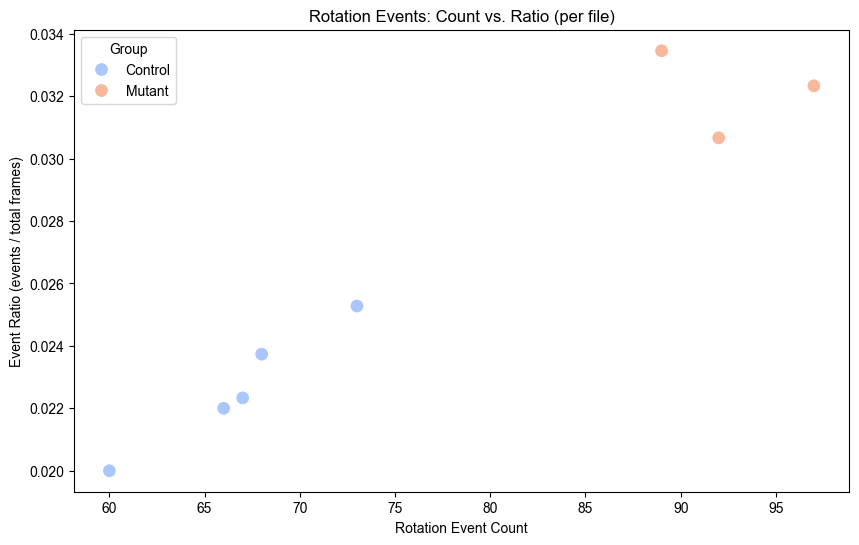

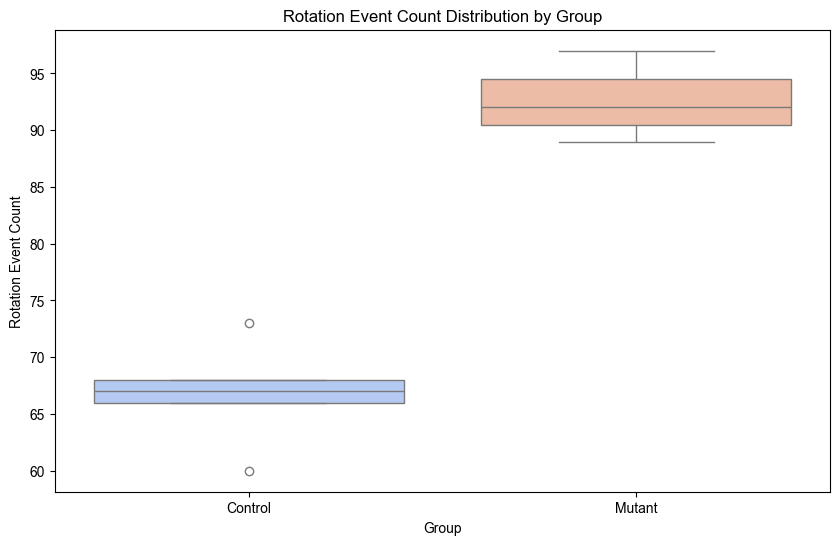

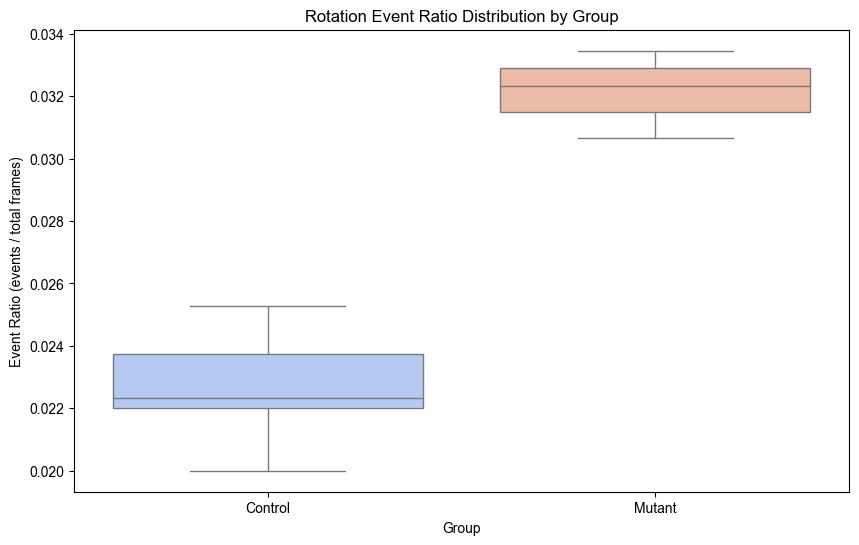

In [89]:
def compute_rotation_file_summary(file_list, rotation_events_df):
    """
    file_list 内の各ファイルについて、CSVから総フレーム数（Frameカラムの最大値＋1）を算出し、
    rotation_events_df におけるそのファイル内の回転イベント数と、全体フレームに対する割合を計算する。
    
    file_list: 対象ファイルパスのリスト
    rotation_events_df: 既に各ファイルごとに検出された回転イベントの DataFrame（'File'カラムあり）
    
    戻り値:
      rotation_file_summary_df (pd.DataFrame): 各ファイルごとの 'File', 'Group', 'total_frames',
                                                 'event_count', 'ratio'（イベント発生割合）の情報を持つ DataFrame
    """
    summary_list = []
    for f in file_list:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"Error reading {f}: {e}")
            continue
        # 総フレーム数はFrameカラムの最大値＋1（フレーム番号が0始まりの場合）
        total_frames = df['Frame'].max() + 1
        file_name = os.path.basename(f)
        # rotation_events_df に同一ファイル名のイベントを抽出
        events_for_file = rotation_events_df[rotation_events_df['File'] == file_name]
        event_count = len(events_for_file)
        ratio = event_count / total_frames if total_frames > 0 else np.nan
        # グループはファイル名の先頭文字で判定（例：'C'→Control, 'D'→Mutant）
        if file_name.startswith('C'):
            group = 'Control'
        elif file_name.startswith('D'):
            group = 'Mutant'
        else:
            group = 'Unknown'
        summary_list.append({
            'File': file_name,
            'Group': group,
            'total_frames': total_frames,
            'event_count': event_count,
            'ratio': ratio
        })
    return pd.DataFrame(summary_list)

# =============================================================================
# 【プロット関数：ファイル別回転イベントの散布図と箱ひげ図】
# =============================================================================
def plot_rotation_events_file_summary(rotation_file_summary_df):
    """
    rotation_file_summary_df の内容を用いて、各ファイルごとの回転イベント数と発生割合を
    散布図と箱ひげ図で可視化する。
    """
    if rotation_file_summary_df.empty:
        print("ファイル別の回転イベントサマリーが存在しません。")
        return
    
    # 散布図：X軸：イベント数, Y軸：割合, 色分け：Group
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rotation_file_summary_df, x='event_count', y='ratio', hue='Group', palette="coolwarm", s=100)
    plt.title("Rotation Events: Count vs. Ratio (per file)")
    plt.xlabel("Rotation Event Count")
    plt.ylabel("Event Ratio (events / total frames)")
    plt.legend(title='Group')
    plt.show()
    
    # 箱ひげ図：グループ別のイベント数
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Group', y='event_count', data=rotation_file_summary_df
               , hue='Group', palette="coolwarm",)
    plt.title("Rotation Event Count Distribution by Group")
    plt.xlabel("Group")
    plt.ylabel("Rotation Event Count")
    plt.show()
    
    # 箱ひげ図：グループ別のイベント割合
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Group', y='ratio', data=rotation_file_summary_df
               , hue='Group', palette="coolwarm",)
    plt.title("Rotation Event Ratio Distribution by Group")
    plt.xlabel("Group")
    plt.ylabel("Event Ratio (events / total frames)")
    plt.show()

# =============================================================================
# 【メイン処理部：回転イベント検出を全ファイルで実施し、ファイル別サマリーを作成・プロット】
# =============================================================================
if __name__ == "__main__":
    # すでに定義した select_frames で対象ファイルリストを取得（ここでは control と mutant の両方）
    Thr_frame = 2500
    control_matrix_files, mutant_matrix_files = select_frames(thr_frame=Thr_frame)
    
    # --- 回転イベント検出（全ファイル） ---
    control_rotation_events_list = []
    for path in tqdm(control_matrix_files, desc="Processing Control Rotation Events"):
        data = pd.read_csv(path)
        data = correct_angles_per_id(data)
        data = smooth_trajectory(data)
        data = detect_id_swaps(data, max_displacement=20)
        rotation_events_df = detect_rotation_events_with_direction(
            data,
            min_event_length=15,
            curvature_threshold=2.5,
            local_window=0,
            max_gap=1
        )
        if not rotation_events_df.empty:
            rotation_events_df['Group'] = 'Control'
            rotation_events_df['File'] = os.path.basename(path)
            control_rotation_events_list.append(rotation_events_df)
            
    mutant_rotation_events_list = []
    for path in tqdm(mutant_matrix_files, desc="Processing Mutant Rotation Events"):
        data = pd.read_csv(path)
        data = correct_angles_per_id(data)
        data = smooth_trajectory(data)
        data = detect_id_swaps(data, max_displacement=20)
        rotation_events_df = detect_rotation_events_with_direction(
            data,
            min_event_length=15,
            curvature_threshold=2.5,
            local_window=0,
            max_gap=1
        )
        if not rotation_events_df.empty:
            rotation_events_df['Group'] = 'Mutant'
            rotation_events_df['File'] = os.path.basename(path)
            mutant_rotation_events_list.append(rotation_events_df)
    
    # 結合
    if control_rotation_events_list or mutant_rotation_events_list:
        all_rotation_events_df = pd.concat(control_rotation_events_list + mutant_rotation_events_list, ignore_index=True)
    else:
        all_rotation_events_df = pd.DataFrame()
    
    print("全ファイルの回転イベント:")
    print(all_rotation_events_df)
    
    # --- ファイル別回転イベントサマリーの作成 ---
    # 対象ファイルは control と mutant 両方のリストを結合
    all_files = control_matrix_files + mutant_matrix_files
    rotation_file_summary_df = compute_rotation_file_summary(all_files, all_rotation_events_df)
    print("ファイル別回転イベントサマリー:")
    print(rotation_file_summary_df)
    
    # --- プロット（散布図・箱ひげ図） ---
    plot_rotation_events_file_summary(rotation_file_summary_df)

In [96]:
def add_stat_annotation(ax, x1, x2, y, p_val, h):
    """
    ax: matplotlib の Axes オブジェクト
    x1, x2: 比較対象の箱（x座標；ここでは0と1と仮定）
    y: 横線の開始y座標
    p_val: 統計検定のp値
    h: オフセット（y軸方向）
    """
    color = 'black'
    # 横線の描画
    ax.plot([x1, x1, x2, x2],
            [y, y + h * 1.2, y + h * 1.2, y],
            color=color)
    # p値に応じたテキスト設定
    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "n.s."
    # 横線中央上部にテキストを描画
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color=color, fontsize=20)

def plot_rotation_events_file_summary(rotation_file_summary_df):
    """
    rotation_file_summary_df の内容を用いて、各ファイルごとの回転イベント数と発生割合を
    散布図と箱ひげ図で可視化する。
    さらに、各箱ひげ図に有意差のアノテーションを追加する。
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import mannwhitneyu

    if rotation_file_summary_df.empty:
        print("ファイル別の回転イベントサマリーが存在しません。")
        return
    
    # --- 散布図 ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rotation_file_summary_df, x='event_count', y='ratio', hue='Group', palette="coolwarm", s=100)
    plt.title("Turn Events: Count vs. Ratio (per file)")
    plt.xlabel("Turn Event Count")
    plt.ylabel("Event Ratio (events / total frames)")
    plt.legend(title='Group')
    plt.show()
    
    # --- 箱ひげ図：グループ別のイベント数 ---
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x='Group', y='event_count', data=rotation_file_summary_df, palette="coolwarm", ax=ax)
    ax.set_title("Turn Event Count Distribution by Group", fontsize=20)
    ax.set_xlabel("Group", fontsize=20)
    ax.set_ylabel("Rotation Event Count", fontsize=20)
    
    # 統計検定（Mann‐Whitney U検定）による有意差判定
    control_counts = rotation_file_summary_df[rotation_file_summary_df['Group']=='Control']['event_count']
    mutant_counts  = rotation_file_summary_df[rotation_file_summary_df['Group']=='Mutant']['event_count']
    stat, p_val = mannwhitneyu(control_counts, mutant_counts, alternative='two-sided')
    # アノテーションの位置を設定（x座標は0と1と仮定）
    y_max = rotation_file_summary_df['event_count'].max()
    y_min = rotation_file_summary_df['event_count'].min()
    h_offset = (y_max - y_min) * 0.1  # 10%の高さをオフセットとして設定
    add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)
    plt.show()
    
    # --- 箱ひげ図：グループ別のイベント割合 ---
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x='Group', y='ratio', data=rotation_file_summary_df, palette="coolwarm", ax=ax)
    ax.set_title("Rotation Event Ratio Distribution by Group", fontsize=20)
    ax.set_xlabel("Group", fontsize=20)
    ax.set_ylabel("Event Ratio (events / total frames)", fontsize=20)
    # 統計検定
    control_ratio = rotation_file_summary_df[rotation_file_summary_df['Group']=='Control']['ratio']
    mutant_ratio  = rotation_file_summary_df[rotation_file_summary_df['Group']=='Mutant']['ratio']
    stat, p_val = mannwhitneyu(control_ratio, mutant_ratio, alternative='two-sided')
    y_max = rotation_file_summary_df['ratio'].max()
    y_min = rotation_file_summary_df['ratio'].min()
    h_offset = (y_max - y_min) * 0.1
    add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)
    plt.show()



def plot_rotation_events_by_files(control_matrix_files, mutant_matrix_files,
                                  min_event_length=15, curvature_threshold=2.5,
                                  local_window=0, max_gap=1, max_displacement=20):
    """
    control_matrix_files と mutant_matrix_files の全ファイルについて、
    回転（くの字）イベントの検出・集計を行い、グループ別（Control / Mutant）の結果を
    ボックスプロットおよび散布図で表示する関数です。

    パラメータ:
      control_matrix_files (list): Control群のCSVファイルパスのリスト
      mutant_matrix_files (list): Mutant群のCSVファイルパスのリスト
      min_event_length (int): 連続して「くの字状態」が続く最低フレーム数
      curvature_threshold (float): 曲がり（curvature）の閾値（この値未満なら十分に曲がっていると判定）
      local_window (int): 局所最小判定に用いる前後フレーム数（0なら単純に閾値判定のみ）
      max_gap (int): 連続グループとして許容するフレーム間ギャップ
      max_displacement (int): IDスワップ検出用の移動距離しきい値
    """
    from tqdm import tqdm
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # --- Control群の全ファイルを処理 ---
    control_rotation_events_list = []
    for path in tqdm(control_matrix_files, desc="Processing Control Rotation Events"):
        data = pd.read_csv(path)
        # 前処理：角度補正、スムージング、IDスワップ修正
        data = correct_angles_per_id(data)
        data = smooth_trajectory(data)
        data = detect_id_swaps(data, max_displacement=max_displacement)
        # 回転イベント検出
        rotation_events_df = detect_rotation_events_with_direction(
            data,
            min_event_length=min_event_length,
            curvature_threshold=curvature_threshold,
            local_window=local_window,
            max_gap=max_gap
        )
        if not rotation_events_df.empty:
            rotation_events_df['Group'] = 'Control'
            rotation_events_df['File'] = os.path.basename(path)
            control_rotation_events_list.append(rotation_events_df)

    # --- Mutant群の全ファイルを処理 ---
    mutant_rotation_events_list = []
    for path in tqdm(mutant_matrix_files, desc="Processing Mutant Rotation Events"):
        data = pd.read_csv(path)
        # 前処理
        data = correct_angles_per_id(data)
        data = smooth_trajectory(data)
        data = detect_id_swaps(data, max_displacement=max_displacement)
        # 回転イベント検出
        rotation_events_df = detect_rotation_events_with_direction(
            data,
            min_event_length=min_event_length,
            curvature_threshold=curvature_threshold,
            local_window=local_window,
            max_gap=max_gap
        )
        if not rotation_events_df.empty:
            rotation_events_df['Group'] = 'Mutant'
            rotation_events_df['File'] = os.path.basename(path)
            mutant_rotation_events_list.append(rotation_events_df)

    # --- 全ファイルの結果を結合 ---
    if control_rotation_events_list or mutant_rotation_events_list:
        all_rotation_events_df = pd.concat(control_rotation_events_list + mutant_rotation_events_list, ignore_index=True)
    else:
        all_rotation_events_df = pd.DataFrame()

    print("全ファイルの回転イベント:")
    print(all_rotation_events_df)

    all_files = control_matrix_files + mutant_matrix_files
    rotation_file_summary_df = compute_rotation_file_summary(all_files, all_rotation_events_df)

    plot_rotation_events_file_summary(rotation_file_summary_df)

Selecting frames from ./csvs/trajectory/C1_L5_ori_overfit.csv
./csvs/trajectory/C1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C2_L5_ori_overfit.csv
./csvs/trajectory/C2_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C3-1_L5_ori_overfit.csv
./csvs/trajectory/C3-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C5-1_L5_ori_overfit.csv
./csvs/trajectory/C5-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/C6_L5_ori_overfit.csv
./csvs/trajectory/C6_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D2_L5_ori_overfit.csv
./csvs/trajectory/D2_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D3-1_L5_ori_overfit.csv
./csvs/trajectory/D3-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D3-2_L4_ori_overfit.csv
./csvs/trajectory/D3-2_L4_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D4-1_L5_ori_overfit.csv
./csvs/trajectory/D4-1_L5_ori_overfit.csv
Selecting frames from ./csvs/trajectory/D5-1_L5_ori_overfit.cs

Processing Control Rotation Events:   0%|                                                                                                         | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_3691/965913594.py:231: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrected_data = data.groupby('ID', group_keys=False).apply(correct_angles)

Smoothing Trajectories: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.67it/s]

Detecting ID Swaps: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1251.66it/s]
/tmp/ipykernel_3691/965913594.py:406:

全ファイルの回転イベント:
     ID  start_frame  end_frame  duration  \
0     1          314        348        35   
1     1          821        850        30   
2     1         1142       1186        45   
3     1         1936       1960        25   
4     1         1975       2020        46   
..   ..          ...        ...       ...   
655   5         2039       2054        16   
656   5         2097       2162        66   
657   5         2402       2435        34   
658   5         2452       2492        41   
659   5         2582       2602        21   

                                          event_frames    Group  \
0    [314, 315, 316, 317, 318, 319, 320, 321, 322, ...  Control   
1    [821, 822, 823, 824, 825, 826, 827, 828, 829, ...  Control   
2    [1142, 1143, 1144, 1145, 1146, 1147, 1148, 114...  Control   
3    [1936, 1937, 1938, 1939, 1940, 1941, 1942, 194...  Control   
4    [1975, 1976, 1977, 1983, 1984, 1985, 1986, 198...  Control   
..                                         

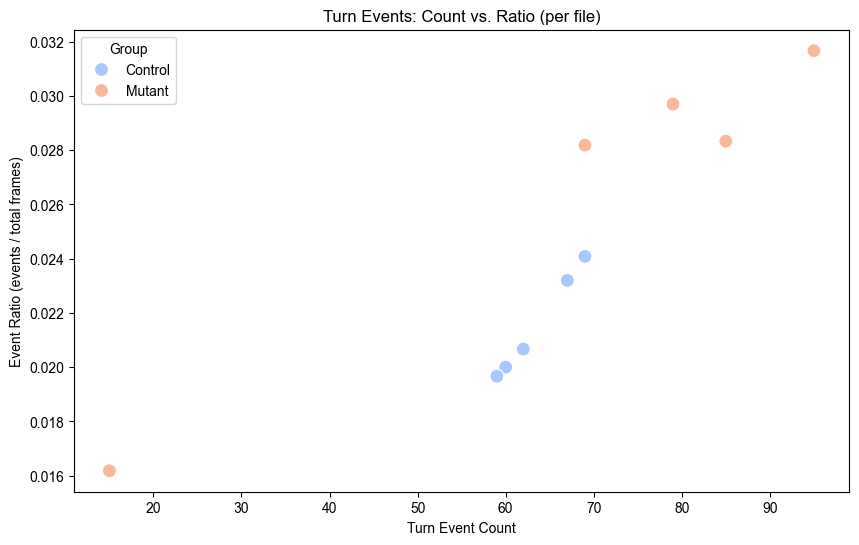

/tmp/ipykernel_3691/945312478.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='event_count', data=rotation_file_summary_df, palette="coolwarm", ax=ax)


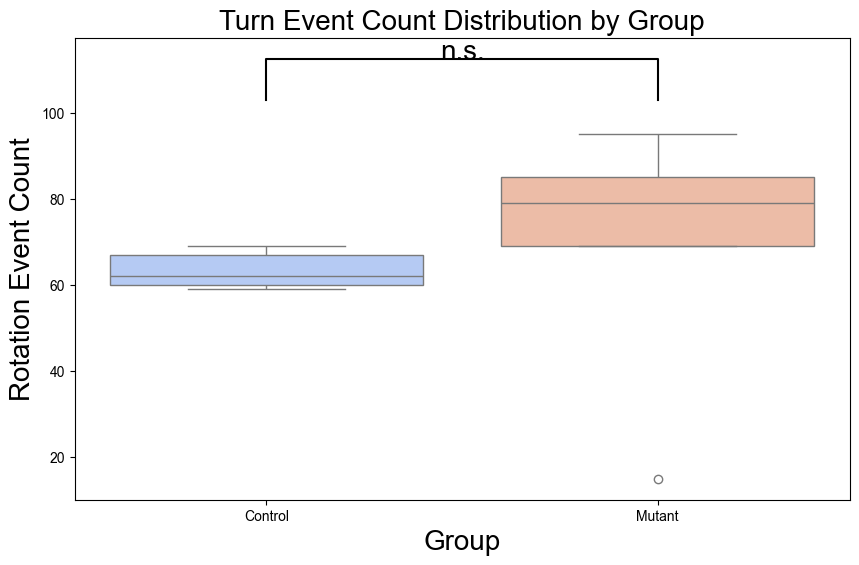

/tmp/ipykernel_3691/945312478.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='ratio', data=rotation_file_summary_df, palette="coolwarm", ax=ax)


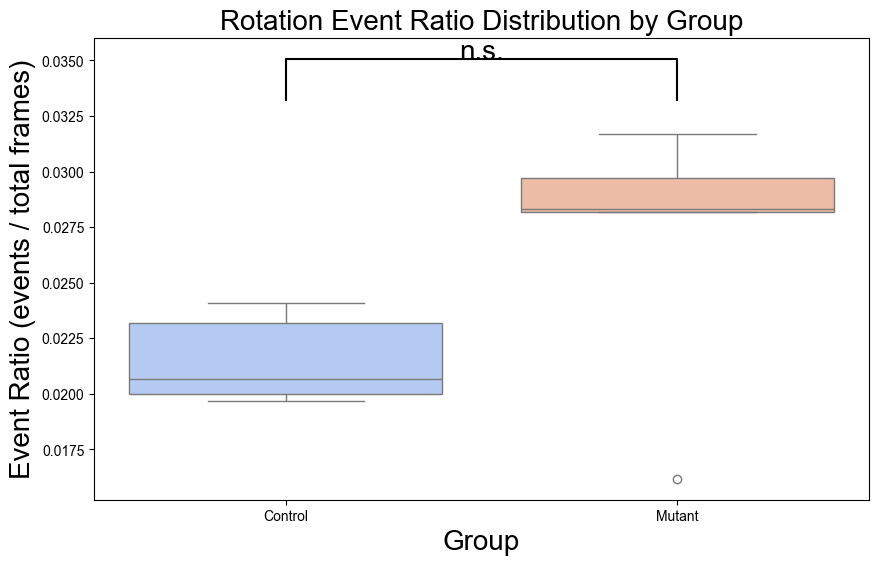

In [99]:
Thr_frame = 100
control_matrix_files, mutant_matrix_files = select_frames(thr_frame=Thr_frame)
plot_rotation_events_by_files(control_matrix_files, mutant_matrix_files, max_gap=5)

In [100]:
control_rotation_events_list = []
for path in tqdm(control_matrix_files, desc="Processing Control Rotation Events"):
    data = pd.read_csv(path)
    data = correct_angles_per_id(data)
    data = smooth_trajectory(data)
    data = detect_id_swaps(data, max_displacement=20)
    rotation_events_df = detect_rotation_events_with_direction(
        data,
        min_event_length=15,
        curvature_threshold=2.5,
        local_window=0,
        max_gap=1
    )
    if not rotation_events_df.empty:
        rotation_events_df['Group'] = 'Control'
        rotation_events_df['File'] = os.path.basename(path)
        control_rotation_events_list.append(rotation_events_df)
        
mutant_rotation_events_list = []
for path in tqdm(mutant_matrix_files, desc="Processing Mutant Rotation Events"):
    data = pd.read_csv(path)
    data = correct_angles_per_id(data)
    data = smooth_trajectory(data)
    data = detect_id_swaps(data, max_displacement=20)
    rotation_events_df = detect_rotation_events_with_direction(
        data,
        min_event_length=15,
        curvature_threshold=2.5,
        local_window=0,
        max_gap=1
    )
    if not rotation_events_df.empty:
        rotation_events_df['Group'] = 'Mutant'
        rotation_events_df['File'] = os.path.basename(path)
        mutant_rotation_events_list.append(rotation_events_df)

# 結合
if control_rotation_events_list or mutant_rotation_events_list:
    all_rotation_events_df = pd.concat(control_rotation_events_list + mutant_rotation_events_list, ignore_index=True)
else:
    all_rotation_events_df = pd.DataFrame()

print("全ファイルの回転イベント:")
print(all_rotation_events_df)

Processing Control Rotation Events:   0%|                                                                                                         | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_3691/965913594.py:231: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrected_data = data.groupby('ID', group_keys=False).apply(correct_angles)

Smoothing Trajectories: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.66it/s]

Detecting ID Swaps: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1222.47it/s]
/tmp/ipykernel_3691/965913594.py:406:

全ファイルの回転イベント:
     ID  start_frame  end_frame  duration  \
0     1          314        348        35   
1     1          821        850        30   
2     1         1142       1186        45   
3     1         1936       1956        21   
4     1         1983       2020        38   
..   ..          ...        ...       ...   
691   5         2097       2125        29   
692   5         2129       2148        20   
693   5         2402       2435        34   
694   5         2452       2492        41   
695   5         2582       2602        21   

                                          event_frames    Group  \
0    [314, 315, 316, 317, 318, 319, 320, 321, 322, ...  Control   
1    [821, 822, 823, 824, 825, 826, 827, 828, 829, ...  Control   
2    [1142, 1143, 1144, 1145, 1146, 1147, 1148, 114...  Control   
3    [1936, 1937, 1938, 1939, 1940, 1941, 1942, 194...  Control   
4    [1983, 1984, 1985, 1986, 1987, 1988, 1989, 199...  Control   
..                                         

In [106]:
all_rotation_events_df.head(40)

,ID,start_frame,end_frame,duration,event_frames,Group,File
0,1,314,348,35,"[314, 315, 316, 317, 318, 319, 320, 321, 322, ...",Control,C1_L5_ori_overfit.csv
1,1,821,850,30,"[821, 822, 823, 824, 825, 826, 827, 828, 829, ...",Control,C1_L5_ori_overfit.csv
2,1,1142,1186,45,"[1142, 1143, 1144, 1145, 1146, 1147, 1148, 114...",Control,C1_L5_ori_overfit.csv
3,1,1936,1956,21,"[1936, 1937, 1938, 1939, 1940, 1941, 1942, 194...",Control,C1_L5_ori_overfit.csv
4,1,1983,2020,38,"[1983, 1984, 1985, 1986, 1987, 1988, 1989, 199...",Control,C1_L5_ori_overfit.csv
5,1,2029,2117,89,"[2029, 2030, 2031, 2032, 2033, 2034, 2035, 203...",Control,C1_L5_ori_overfit.csv
6,1,2588,2604,17,"[2588, 2589, 2590, 2591, 2592, 2593, 2594, 259...",Control,C1_L5_ori_overfit.csv
7,1,2608,2632,25,"[2608, 2609, 2610, 2611, 2612, 2613, 2614, 261...",Control,C1_L5_ori_overfit.csv
8,1,2677,2730,54,"[2677, 2678, 2679, 2680, 2681, 2682, 2683, 268...",Control,C1_L5_ori_overfit.csv
9,2,42,74,33,"[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 5...",Control,C1_L5_ori_overfit.csv


# Following

In [107]:
def compute_heading(df):
    """
    各個体ごとに、連続する2点間の座標から進行方向（heading）を計算し、新たなカラム "heading" として追加する。
    heading はラジアンで算出します。
    """
    df = df.sort_values(["ID", "Frame"]).copy()
    df["heading"] = df.groupby("ID").apply(
        lambda g: np.arctan2(g["Head_Y"].diff(), g["Head_X"].diff())
    ).reset_index(level=0, drop=True)
    return df

def group_consecutive_frames(frames, max_gap=1):
    """
    ソート済みのフレーム番号リスト frames を、各フレーム間のギャップが max_gap 以下なら同一グループとし、
    連続しているフレーム群のリストを返す。
    """
    frames = sorted(frames)
    groups = []
    current_group = []
    for f in frames:
        if not current_group:
            current_group.append(f)
        elif f - current_group[-1] <= max_gap:
            current_group.append(f)
        else:
            groups.append(current_group)
            current_group = [f]
    if current_group:
        groups.append(current_group)
    return groups

def extract_tracking_events(df, distance_threshold=50, heading_threshold=np.deg2rad(20), min_duration=5):
    """
    df: 追跡対象の軌跡データ（pandas DataFrame）。必須カラムは 'Frame', 'ID', 'Head_X', 'Head_Y'。
    distance_threshold: 2個体間の距離がこの閾値未満なら「近い」と判定（単位は座標の単位）
    heading_threshold: 2個体の進行方向の差がこの閾値未満なら「同じ方向」と判定（ラジアン）
    min_duration: 追跡状態と判定するための連続フレーム数の最小値

    戻り値:
      tracking_events_df (pandas DataFrame): 各個体ペアごとに追跡イベントがあったフレーム区間を
      'id1', 'id2', 'start_frame', 'end_frame', 'duration' として返す。
    """
    # まず、各個体ごとに heading を計算
    df = compute_heading(df)
    
    events = []
    ids = df["ID"].unique()
    # 個体ペアごとに処理（順序は組み合わせなので、id1 と id2 が同じ組み合わせは1回のみ）
    for i, id1 in enumerate(ids):
        for id2 in ids[i+1:]:
            # id1, id2 のデータをそれぞれ抽出し、Frameをキーにマージ
            df1 = df[df["ID"] == id1][["Frame", "Head_X", "Head_Y", "heading"]].rename(
                columns={"Head_X": "X1", "Head_Y": "Y1", "heading": "heading1"}
            )
            df2 = df[df["ID"] == id2][["Frame", "Head_X", "Head_Y", "heading"]].rename(
                columns={"Head_X": "X2", "Head_Y": "Y2", "heading": "heading2"}
            )
            merged = pd.merge(df1, df2, on="Frame")
            if merged.empty:
                continue
            # 距離の計算
            merged["dist"] = np.sqrt((merged["X1"] - merged["X2"])**2 + (merged["Y1"] - merged["Y2"])**2)
            # heading差の計算（-pi～piに正規化）
            merged["heading_diff"] = np.abs((merged["heading1"] - merged["heading2"] + np.pi) % (2 * np.pi) - np.pi)
            # 条件を満たすフレームを抽出
            merged["tracking"] = (merged["dist"] < distance_threshold) & (merged["heading_diff"] < heading_threshold)
            tracking_frames = merged[merged["tracking"]]["Frame"].tolist()
            groups = group_consecutive_frames(tracking_frames, max_gap=1)
            for group in groups:
                if len(group) >= min_duration:
                    events.append({
                        "id1": id1,
                        "id2": id2,
                        "start_frame": group[0],
                        "end_frame": group[-1],
                        "duration": group[-1] - group[0] + 1
                    })
    return pd.DataFrame(events)


In [154]:
def extract_tracking_events(df, distance_threshold=50, heading_threshold=np.deg2rad(20), min_duration=5, coordinate_A="Head", coordinate_others=["Head", "Middle", "Tail"]):
    """
    df: 軌跡データの DataFrame（必須カラム: 'Frame', 'ID', それぞれの部位の座標）
    distance_threshold: 距離の閾値
    heading_threshold: 進行方向の差の閾値（ラジアン）
    min_duration: 追跡状態と認めるための連続フレーム数
    coordinate_A: 追跡対象の個体Aの代表座標。例: "Head"
    coordinate_others: 他個体の候補部位のリスト。例: ["Head", "Middle", "Tail"]
    
    戻り値:
      tracking_events_df: 各個体ペアについて追跡状態が認められたフレーム区間を記録した DataFrame
      （カラム例: ['id1', 'id2', 'start_frame', 'end_frame', 'duration']）
    """
    df = df.copy()
    # ここでは、時系列の各フレームごとに、対象となる全個体ペアについて距離を計算する方法をとります。
    events = []
    ids = df["ID"].unique()
    for i, id1 in enumerate(ids):
        for id2 in ids[i+1:]:
            df1 = df[df["ID"] == id1][["Frame", f"{coordinate_A}_X", f"{coordinate_A}_Y"]].rename(
                columns={f"{coordinate_A}_X": "X1", f"{coordinate_A}_Y": "Y1"}
            )
            df2 = df[df["ID"] == id2][["Frame"]].copy()
            # 他個体の候補座標について最小距離を計算
            min_d_list = []
            for _, row in df1.iterrows():
                frame = row["Frame"]
                A_pos = np.array([row["X1"], row["Y1"]])
                # 他個体 (id2) の全ての候補部位
                df2_frame = df[(df["Frame"]==frame) & (df["ID"]==id2)]
                d_vals = []
                for coord in coordinate_others:
                    if f"{coord}_X" in df2_frame.columns and f"{coord}_Y" in df2_frame.columns:
                        pos = df2_frame[[f"{coord}_X", f"{coord}_Y"]].values
                        if pos.shape[0] > 0:
                            d_vals.append(np.min(np.linalg.norm(pos - A_pos, axis=1)))
                if len(d_vals) > 0:
                    min_d_list.append((frame, np.min(d_vals)))
            # 時系列のフレーム番号で抽出
            frames_met = [f for f, d in min_d_list if d < distance_threshold]
            groups = group_consecutive_frames(frames_met, max_gap=1)
            for group in groups:
                if len(group) >= min_duration:
                    events.append({
                        "id1": id1,
                        "id2": id2,
                        "start_frame": group[0],
                        "end_frame": group[-1],
                        "duration": group[-1] - group[0] + 1
                    })
    return pd.DataFrame(events)



In [158]:
df = pd.read_csv(control_matrix_files[0])
tracking_events_df = extract_tracking_events(df,
                                             distance_threshold=30,
                                             heading_threshold=np.deg2rad(20),
                                             min_duration=5,
                                             coordinate_A="Head",
                                             coordinate_others=["Head", "Middle", "Tail"])


In [159]:
tracking_events_df.sort_values(['start_frame'])

,id1,id2,start_frame,end_frame,duration
20,2,4,251.0,281.0,31.0
21,2,4,284.0,288.0,5.0
8,1,4,451.0,492.0,42.0
23,3,4,473.0,492.0,20.0
5,1,3,475.0,542.0,68.0
9,1,4,534.0,546.0,13.0
24,3,4,534.0,542.0,9.0
25,3,4,548.0,582.0,35.0
10,1,4,558.0,565.0,8.0
26,3,4,588.0,624.0,37.0


# 密度推定

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from shapely.geometry import MultiPoint

# ========================================================
# 1. 入力データから座標抽出用の関数
# ========================================================
def extract_points(df, coordinate='Middle'):
    """
    df: DataFrame。必須カラム: 'Frame', 'ID', 'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y', 'Tail_X', 'Tail_Y'
    coordinate: 'Head', 'Middle', 'Tail' のいずれか。各点の代表座標として使用するカラムを指定する。
    
    戻り値:
      points: 指定した座標の numpy.array (shape=(n,2))。ここではすべての行（全フレーム）の点を返す。
    """
    if coordinate == 'Head':
        pts = df[['Head_X', 'Head_Y']].values
    elif coordinate == 'Tail':
        pts = df[['Tail_X', 'Tail_Y']].values
    else:
        pts = df[['Middle_X', 'Middle_Y']].values
    return pts

# ========================================================
# 2. 局所密度 (Local Density) の計算
# ========================================================
def compute_local_density(points, radius):
    """
    points: shape (n,2) の numpy.array（各行が [x, y]）
    radius: 半径（単位は入力座標の単位）
    
    各点について、その点を中心に半径 radius 内に存在する他の点の数を計算する。
    戻り値:
      local_counts: 各点の局所密度（カウント）の numpy.array
    """
    n = points.shape[0]
    dmat = distance_matrix(points, points)
    # 自分自身は0なのでカウントから除外
    local_counts = (dmat <= radius).sum(axis=1) - 1
    return local_counts

# ========================================================
# 3. Ripley’s K 関数・L 関数 の計算
# ========================================================
def ripley_K(points, r_values, area=None):
    """
    points: shape (n,2) の numpy.array
    r_values: 評価する距離の配列
    area: 点群の全体領域面積（None の場合は Convex Hull を使って近似）
    
    戻り値:
      K_values: r_values に対する Ripley's K 関数の値（numpy.array）
    """
    n = points.shape[0]
    if area is None:
        # Convex Hull を用いて面積を近似
        hull = MultiPoint(points).convex_hull
        area = hull.area

    dmat = distance_matrix(points, points)
    K_values = []
    for r in r_values:
        # 対角（自分自身）は除くため n を引き、また各ペアが2回カウントされるので2で割る
        count = (dmat <= r).sum() - n
        count = count / 2
        K_r = (area / (n**2)) * count
        K_values.append(K_r)
    return np.array(K_values)

def ripley_L(K_values, r_values):
    """
    Ripley's L 関数は L(r)=sqrt(K(r)/pi) と定義される。
    
    戻り値:
      L_values: numpy.array
    """
    return np.sqrt(K_values / np.pi)

# ========================================================
# 4. 時系列全体の解析を行う関数
# ========================================================
def analyze_trajectory_timeseries(df, coordinate='Middle', radius=50, r_values=None):
    """
    df: 軌跡データの DataFrame。必須カラム: 'Frame', 'ID', 'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y', 'Tail_X', 'Tail_Y'
    coordinate: 使用する座標。'Middle' (デフォルト) など
    radius: 局所密度計算時に用いる半径
    r_values: Ripley’s K 関数・L 関数を評価する距離の配列（Noneの場合は自動生成）
    
    処理内容:
      1. 各フレームごとに、対象座標から局所密度（各点のカウント）を計算し、その平均を記録。
      2. 全フレームの点を統合して、全体としての Ripley’s K 関数・L 関数 を計算・プロットする。
    
    戻り値:
      frame_density: 各フレームごとの平均局所密度の辞書 {frame: value}
    """
    # DataFrame をフレームでソート
    df = df.sort_values('Frame')
    frames = df['Frame'].unique()
    frame_density = {}
    
    # 各フレームごとに局所密度を計算
    for frame in frames:
        df_frame = df[df['Frame'] == frame]
        points = extract_points(df_frame, coordinate=coordinate)
        if points.shape[0] == 0:
            continue
        densities = compute_local_density(points, radius)
        frame_density[frame] = np.mean(densities)
    
    # プロット: フレームごとの平均局所密度の時系列
    plt.figure(figsize=(10, 6))
    frame_list = sorted(frame_density.keys())
    density_vals = [frame_density[f] for f in frame_list]
    plt.plot(frame_list, density_vals, marker='o', linestyle='-')
    plt.xlabel("Frame")
    plt.ylabel("Average Local Density (count within radius={})".format(radius))
    plt.title("Time Series of Average Local Density")
    plt.show()
    
    # 時系列全体の解析：すべてのフレームの点を統合して解析
    all_points = extract_points(df, coordinate=coordinate)
    overall_densities = compute_local_density(all_points, radius)
    overall_avg_density = np.mean(overall_densities)
    print("全体の平均局所密度:", overall_avg_density)
    
    # Ripley's K 関数／L 関数 の計算
    if r_values is None:
        r_values = np.linspace(0, radius*2, 100)
    K_vals = ripley_K(all_points, r_values)
    L_vals = ripley_L(K_vals, r_values)
    
    # プロット: Ripley's L(r) - r
    plt.figure(figsize=(10, 6))
    plt.plot(r_values, L_vals - r_values, label="L(r) - r")
    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("r")
    plt.ylabel("L(r) - r")
    plt.title("Ripley's L Function (Aggregated over all frames)")
    plt.legend()
    plt.show()
    
    return frame_density



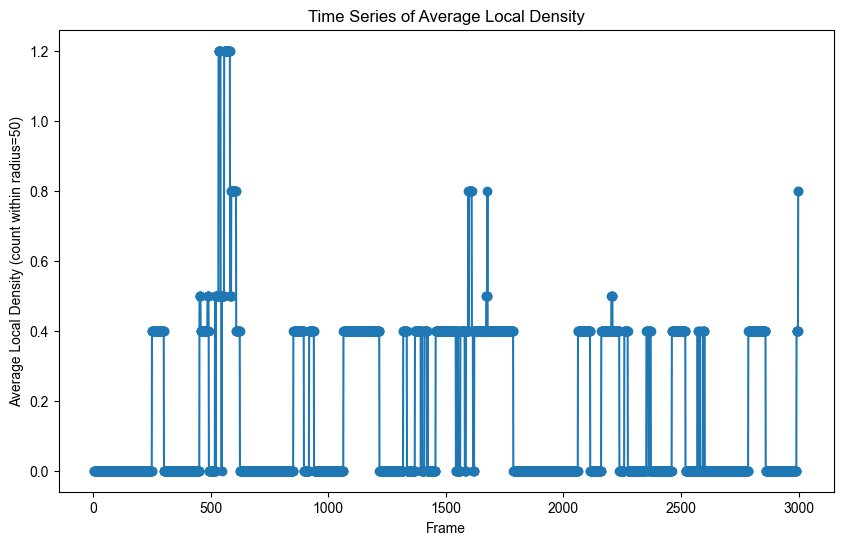

全体の平均局所密度: 907.8007300256861


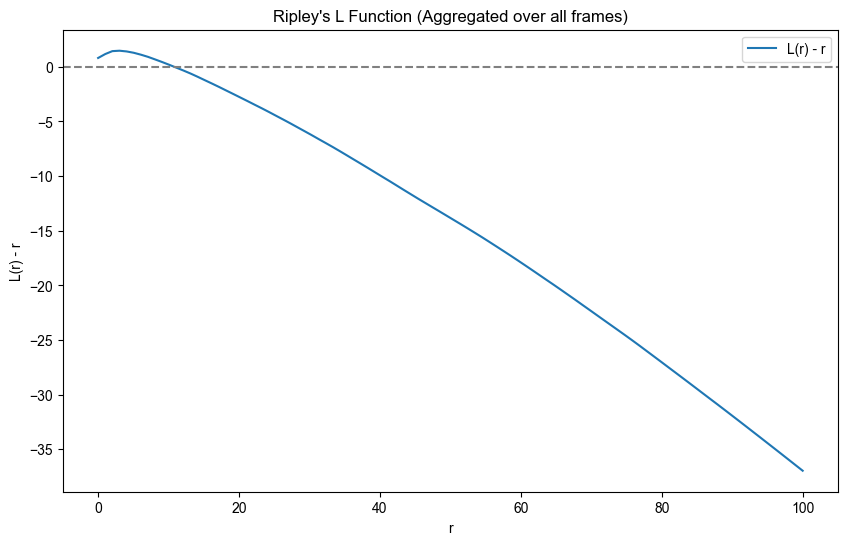

{4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.0,
 31: 0.0,
 32: 0.0,
 33: 0.0,
 34: 0.0,
 35: 0.0,
 36: 0.0,
 37: 0.0,
 38: 0.0,
 39: 0.0,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.0,
 44: 0.0,
 45: 0.0,
 46: 0.0,
 47: 0.0,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.0,
 56: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 60: 0.0,
 61: 0.0,
 62: 0.0,
 63: 0.0,
 64: 0.0,
 65: 0.0,
 66: 0.0,
 67: 0.0,
 68: 0.0,
 69: 0.0,
 70: 0.0,
 71: 0.0,
 72: 0.0,
 73: 0.0,
 74: 0.0,
 75: 0.0,
 76: 0.0,
 77: 0.0,
 78: 0.0,
 79: 0.0,
 80: 0.0,
 81: 0.0,
 82: 0.0,
 83: 0.0,
 84: 0.0,
 85: 0.0,
 86: 0.0,
 87: 0.0,
 88: 0.0,
 89: 0.0,
 90: 0.0,
 91: 0.0,
 92: 0.0,
 93: 0.0,
 94: 0.0,
 95: 0.0,
 96: 0.0,
 97: 0.0,
 98: 0.0,
 99: 0.0,
 100: 0.0,
 101: 0.0,
 102: 0.0,
 103: 0.0,
 1

In [120]:
analyze_trajectory_timeseries(df)

# 最短距離

In [121]:
# ----------------------------------------------
# (1) 各フレームごとに、すべてのIDごとの最小距離を計算する関数
# ----------------------------------------------
def compute_all_min_distances(df, focal_coordinate="Head", other_coordinates=["Head", "Middle", "Tail"]):
    """
    入力の DataFrame df は、必ず 'Frame', 'ID', 
    'Head_X', 'Head_Y', 'Middle_X', 'Middle_Y', 'Tail_X', 'Tail_Y' の各カラムを持つものとする。

    focal_coordinate: 追跡対象個体の代表座標として使用する部位。たとえば "Head" を指定すると、
                        各個体の Head 座標が focal 座標となる。
    other_coordinates: 他個体の候補部位。例として ["Head", "Middle", "Tail"] を指定すると、
                       他個体の Head, Middle, Tail の各座標の中で、一番近いものとの距離を採用する。

    戻り値:
      df_result: 各フレームにおいて各個体の最小距離（min_dist）を追加した DataFrame。
                 カラム例: ['Frame', 'ID', ..., 'min_dist']
    """
    df = df.copy()
    # 結果用のリスト
    results = []
    # 各フレームごとに処理
    for frame, group in df.groupby("Frame"):
        # group はそのフレームの全個体のデータ
        # まず、各個体の focal 座標を取得（例："Head_X", "Head_Y"）
        focal_x = group[f"{focal_coordinate}_X"].values
        focal_y = group[f"{focal_coordinate}_Y"].values
        focal_coords = np.vstack([focal_x, focal_y]).T  # shape (n,2)
        
        # 他個体の候補座標は、各個体ごとに個別に計算するので、まず全個体のデータを辞書にする
        # ここでは、対象群全体で同じ候補カラムを用いるので、後で各個体ごとにループ処理
        candidate_coords = {}
        for coord in other_coordinates:
            candidate_x = group[f"{coord}_X"].values
            candidate_y = group[f"{coord}_Y"].values
            candidate_coords[coord] = np.vstack([candidate_x, candidate_y]).T  # shape (n,2)
        
        # 各個体について、他の全個体との距離を計算
        n = focal_coords.shape[0]
        # ここで、各個体の最小距離（他個体との比較）
        min_dists = np.empty(n)
        for i in range(n):
            # focal個体 i の座標
            coord_i = focal_coords[i].reshape(1, -1)  # shape (1,2)
            # 初期値：大きな値
            d_min = np.inf
            # 他の個体 j
            for j in range(n):
                if i == j:
                    continue
                # j番目の候補座標群（複数部位の中で最小）
                for coord in other_coordinates:
                    candidate = candidate_coords[coord][j].reshape(1, -1)  # shape (1,2)
                    d = np.linalg.norm(coord_i - candidate)
                    if d < d_min:
                        d_min = d
            # もし他個体が存在しなければ d_min は np.inf のまま、ここでは NaN に変換
            if d_min == np.inf:
                d_min = np.nan
            min_dists[i] = d_min
        
        group = group.copy()
        group["min_dist"] = min_dists
        results.append(group)
    
    df_result = pd.concat(results, ignore_index=True)
    return df_result

# ----------------------------------------------
# (2) 個体ごとに時系列の min_dist を集計する例
# ----------------------------------------------
def summarize_min_distances(df):
    """
    df は compute_all_min_distances() により min_dist カラムが追加された DataFrame とする。
    各個体ごとに、全フレームにわたる min_dist の平均・中央値・標準偏差などを算出する。

    戻り値:
      summary_df: 各個体ごとの統計指標をまとめた DataFrame
    """
    summary = df.groupby("ID")["min_dist"].agg(["mean", "median", "std", "min", "max", "count"]).reset_index()
    summary = summary.rename(columns={"mean": "mean_dist", "median": "median_dist",
                                        "std": "std_dist", "min": "min_dist", "max": "max_dist", "count": "n_frames"})
    return summary

各個体ごとの最小距離のサマリー:
   ID   mean_dist  median_dist   std_dist  min_dist    max_dist  n_frames
0   1   72.333251    61.336947  51.966297  1.777302  249.669514      2975
1   2   71.479371    61.869507  44.644390  1.210680  202.769028      2959
2   3   78.180201    68.188272  59.758324  1.029020  294.578913      2959
3   4   96.389263    82.432904  63.324446  1.029020  259.914701      2945
4   5  106.527164    87.171888  68.740916  1.276748  312.802918      2956


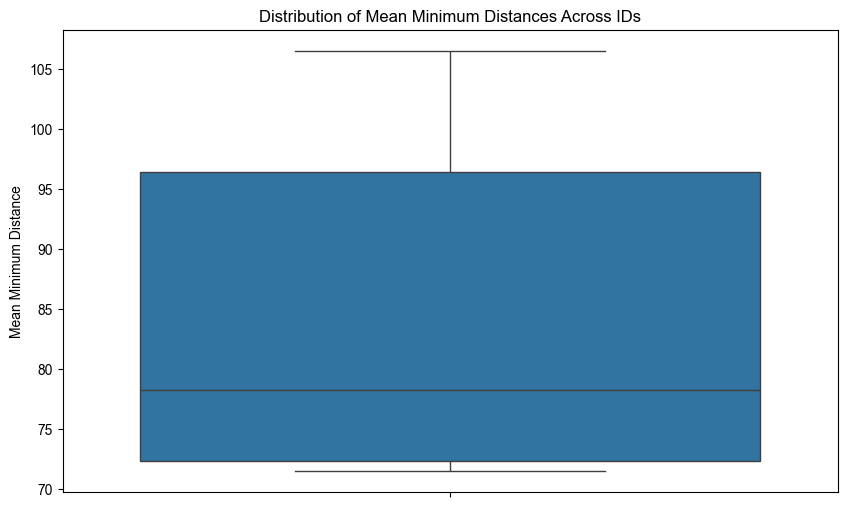

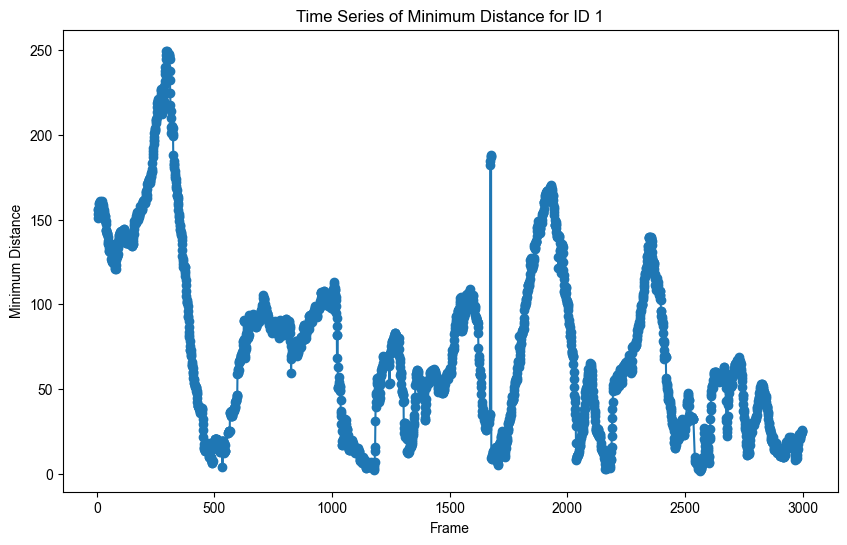

In [122]:
# すべてのフレームで、各個体ごとの最小距離を計算する
df_min = compute_all_min_distances(df, focal_coordinate="Head", other_coordinates=["Head", "Middle", "Tail"])

# 各個体ごとに統計指標を算出
summary_df = summarize_min_distances(df_min)
print("各個体ごとの最小距離のサマリー:")
print(summary_df)

# 例として、個体ごとの平均距離の分布を箱ひげ図で可視化
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=summary_df, y="mean_dist")
plt.title("Distribution of Mean Minimum Distances Across IDs")
plt.ylabel("Mean Minimum Distance")
plt.show()

# さらに、時系列プロットとして、ある個体の min_dist の推移をプロットする例
# ここでは、ID=1 のデータを例にとる
df_id1 = df_min[df_min["ID"] == 1]
plt.figure(figsize=(10, 6))
plt.plot(df_id1["Frame"], df_id1["min_dist"], marker='o', linestyle='-')
plt.xlabel("Frame")
plt.ylabel("Minimum Distance")
plt.title("Time Series of Minimum Distance for ID 1")
plt.show()


In [135]:
summary_df_control = pd.DataFrame()
for path in control_matrix_files:
    df = pd.read_csv(path)
    df_min = compute_all_min_distances(df, focal_coordinate="Head", other_coordinates=["Head", "Middle", "Tail"])
    summary_df = summarize_min_distances(df_min)
    summary_df_control = pd.concat([summary_df_control, summary_df])

summary_df_mutant = pd.DataFrame()
for path in mutant_matrix_files:
    df = pd.read_csv(path)
    df_min = compute_all_min_distances(df, focal_coordinate="Head", other_coordinates=["Head", "Middle", "Tail"])
    summary_df = summarize_min_distances(df_min)
    summary_df_mutant = pd.concat([summary_df_mutant, summary_df])

summary_df_control['type'] = 'control'
summary_df_mutant['type'] = 'mutant'

summary_df_concat = pd.concat([summary_df_control, summary_df_mutant])

In [137]:
def add_stat_annotation(ax, x1, x2, y, p_val, h):
    """
    ax: matplotlib の Axes オブジェクト
    x1, x2: 比較対象の箱（x座標；ここでは0と1と仮定）
    y: 横線の開始y座標
    p_val: 統計検定のp値
    h: オフセット（y軸方向）
    """
    color = 'black'
    # 横線の描画
    ax.plot([x1, x1, x2, x2],
            [y, y + h * 1.2, y + h * 1.2, y],
            color=color)
    # p値に応じたテキスト設定
    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "n.s."
    # 横線中央上部にテキストを描画
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color=color, fontsize=20)

/tmp/ipykernel_3691/1342975668.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='mean_dist', data=summary_df_concat, palette="coolwarm", ax=ax,
/tmp/ipykernel_3691/1342975668.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='type', y='mean_dist', data=summary_df_concat, palette="coolwarm", ax=ax,
/tmp/ipykernel_3691/1342975668.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=15)


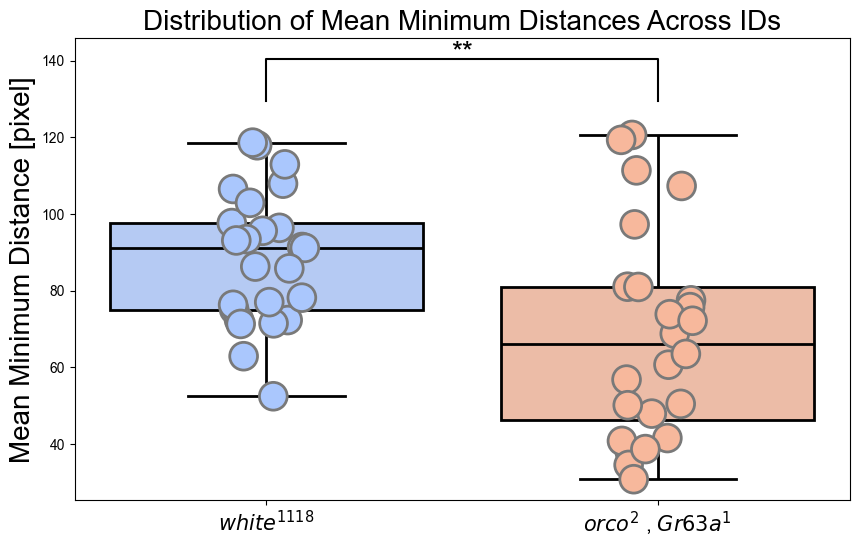

In [160]:
from scipy.stats import mannwhitneyu
control_values = summary_df_control['mean_dist'].dropna().values
mutant_values  = summary_df_mutant['mean_dist'].dropna().values

#PIXEL_TO_MM = 0.06

stat, p_val = mannwhitneyu(control_values, mutant_values, alternative='two-sided')

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='type', y='mean_dist', data=summary_df_concat, palette="coolwarm", ax=ax,
        linecolor="k",
        linewidth=2,)
sns.stripplot(x='type', y='mean_dist', data=summary_df_concat, palette="coolwarm", ax=ax,
             s = 20, linewidth=2)
ax.set_title("Distribution of Mean Minimum Distances Across IDs", fontsize=20)
ax.set_xlabel("", fontsize=20)
ax.set_ylabel("Mean Minimum Distance [pixel]", fontsize=20)
labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
ax.set_xticklabels(labels, fontsize=15)

y_max = summary_df_concat['mean_dist'].max()
y_min = summary_df_concat['mean_dist'].min()
h_offset = (y_max - y_min) * 0.1
add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)

/tmp/ipykernel_3691/438062000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='mean_dist', data=summary_df_concat, palette="coolwarm", ax=ax,


Text(0, 0.5, 'Event Ratio (events / total frames)')

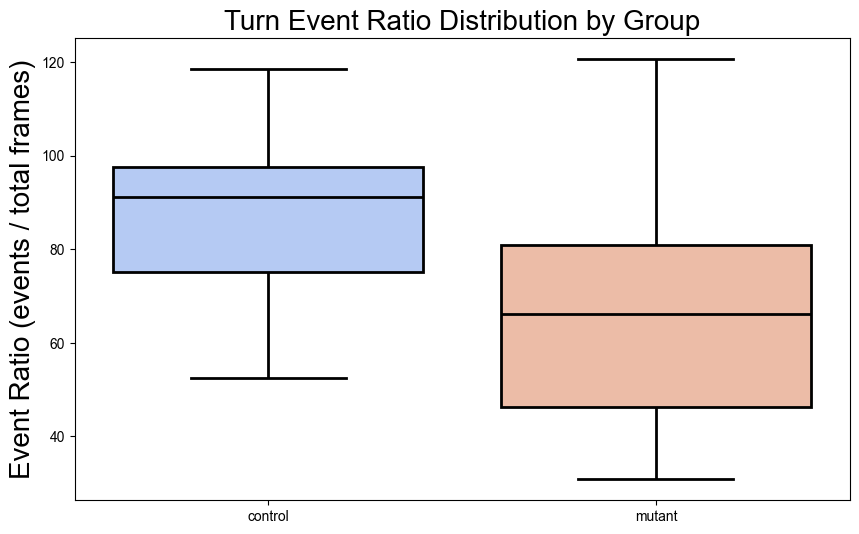

In [144]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='type', y='mean_dist', data=summary_df_concat, palette="coolwarm", ax=ax,
        linecolor="k",
        linewidth=2,)
ax.set_title("Turn Event Ratio Distribution by Group", fontsize=20)
ax.set_xlabel("", fontsize=20)
ax.set_ylabel("Event Ratio (events / total frames)", fontsize=20)

# 色々試す

In [161]:
def compute_proximity_ratio(df, threshold, id_col="ID", frame_col="Frame", x_col="Head_X", y_col="Head_Y"):
    """
    df: 軌跡データの DataFrame
    threshold: 距離のしきい値（例: 50）
    Returns: 各個体ごとに、近接状態（最近接距離 < threshold）となるフレームの割合
    """
    # 各フレームごとに処理して、最近接距離を計算
    results = []
    for frame, group in df.groupby(frame_col):
        group = group.copy()
        pts = group[[x_col, y_col]].values
        if len(pts) < 2:
            group['nnd'] = np.nan
        else:
            dmat = distance_matrix(pts, pts)
            np.fill_diagonal(dmat, np.inf)
            group['nnd'] = dmat.min(axis=1)
        results.append(group)
    df2 = pd.concat(results, ignore_index=True)
    summary = df2.groupby(id_col).apply(lambda g: pd.Series({
        'proximity_ratio': np.mean(g['nnd'] < threshold)
    })).reset_index()
    return summary




In [164]:
summary_df_control = pd.DataFrame()
for path in control_matrix_files:
    df = pd.read_csv(path)
    proximity_summary = compute_proximity_ratio(df, threshold=50, id_col="ID", frame_col="Frame", x_col="Head_X", y_col="Head_Y")
    summary_df_control = pd.concat([summary_df_control, proximity_summary])

summary_df_mutant = pd.DataFrame()
for path in mutant_matrix_files:
    df = pd.read_csv(path)
    proximity_summary = compute_proximity_ratio(df, threshold=50, id_col="ID", frame_col="Frame", x_col="Head_X", y_col="Head_Y")
    summary_df_mutant = pd.concat([summary_df_mutant, proximity_summary])

summary_df_control['type'] = 'control'
summary_df_mutant['type'] = 'mutant'

summary_df_concat = pd.concat([summary_df_control, summary_df_mutant])

/tmp/ipykernel_3691/2727644387.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df2.groupby(id_col).apply(lambda g: pd.Series({
/tmp/ipykernel_3691/2727644387.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df2.groupby(id_col).apply(lambda g: pd.Series({
/tmp/ipykernel_3691/2727644387.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

/tmp/ipykernel_3691/105269634.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='proximity_ratio', data=summary_df_concat, palette="coolwarm", ax=ax,
/tmp/ipykernel_3691/105269634.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='type', y='proximity_ratio', data=summary_df_concat, palette="coolwarm", ax=ax,
/tmp/ipykernel_3691/105269634.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=15)


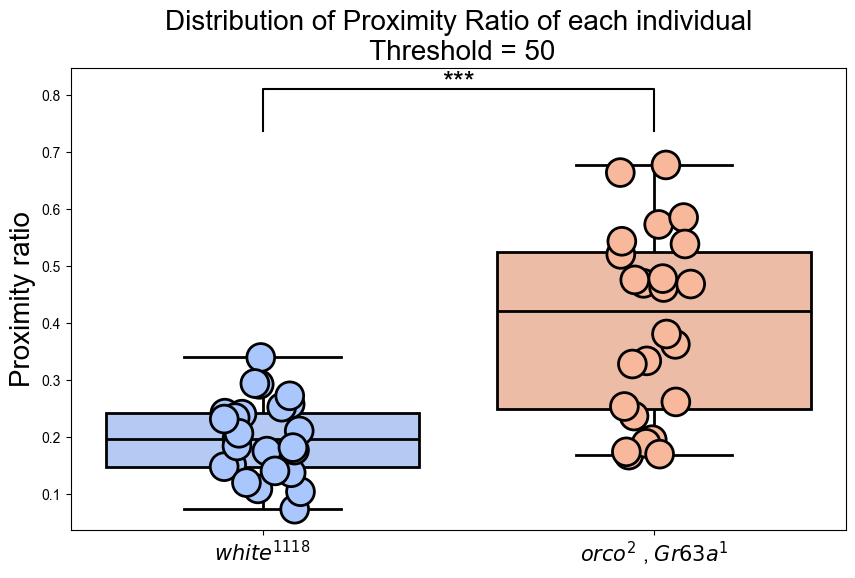

In [169]:
from scipy.stats import mannwhitneyu
control_values = summary_df_control['proximity_ratio'].dropna().values
mutant_values  = summary_df_mutant['proximity_ratio'].dropna().values

#PIXEL_TO_MM = 0.06

stat, p_val = mannwhitneyu(control_values, mutant_values, alternative='two-sided')

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='type', y='proximity_ratio', data=summary_df_concat, palette="coolwarm", ax=ax,
        linecolor="k",
        linewidth=2,)
sns.stripplot(x='type', y='proximity_ratio', data=summary_df_concat, palette="coolwarm", ax=ax,
              edgecolor="k",
             s = 20, linewidth=2)
Thr = 50
ax.set_title(f"Distribution of Proximity Ratio of each individual\n Threshold = {Thr}", fontsize=20)
ax.set_xlabel("", fontsize=20)
ax.set_ylabel("Proximity ratio", fontsize=20)
labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
ax.set_xticklabels(labels, fontsize=15)

y_max = summary_df_concat['proximity_ratio'].max()
y_min = summary_df_concat['proximity_ratio'].min()
h_offset = (y_max - y_min) * 0.1
add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)

In [170]:
summary_df_mutant

,ID,proximity_ratio,type
0,1,0.572934,mutant
1,2,0.585058,mutant
2,3,0.469553,mutant
3,4,0.462248,mutant
4,5,0.468363,mutant
0,1,0.362436,mutant
1,2,0.333479,mutant
2,3,0.167997,mutant
3,4,0.261397,mutant
4,5,0.327941,mutant


In [177]:
df = pd.read_csv(mutant_matrix_files[-1])
id_col="ID"
frame_col="Frame"
x_col="Head_X"
y_col="Head_Y"
threshold = 50
results = []
for frame, group in df.groupby(frame_col):
    group = group.copy()
    pts = group[[x_col, y_col]].values
    if len(pts) < 2:
        group['nnd'] = np.nan
    else:
        dmat = distance_matrix(pts, pts)
        np.fill_diagonal(dmat, np.inf)
        group['nnd'] = dmat.min(axis=1)
    results.append(group)
df2 = pd.concat(results, ignore_index=True)
summary = df2.groupby(id_col).apply(lambda g: pd.Series({
    'proximity_ratio': np.mean(g['nnd'] < threshold)
})).reset_index()

/tmp/ipykernel_3691/762060142.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df2.groupby(id_col).apply(lambda g: pd.Series({


In [187]:
 df2.groupby(id_col).apply(lambda g: pd.Series({
    'proximity_ratio': np.mean(g['nnd'] < threshold)
})).reset_index()

/tmp/ipykernel_3691/2292697167.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2.groupby(id_col).apply(lambda g: pd.Series({


,ID,proximity_ratio
0,1,0.475600
1,2,0.173794
2,3,0.538677
3,4,0.380609
4,5,0.664016


In [196]:
def select_frames_of_contact_events(thr_frame = 5000): 
    control_matrix_files = []
    for path in natsorted(glob.glob('./csvs/interaction_matrcies/contact_events_C*')):
        df = pd.read_csv(path)
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(path))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        if total_frames > thr_frame:
            print(path)
            control_matrix_files.append(path)

    mutant_matrix_files = []
    for path in natsorted(glob.glob('./csvs/interaction_matrcies/contact_events_D*')):
        df = pd.read_csv(path)
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(path))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        if total_frames > thr_frame:
            print(path)
            mutant_matrix_files.append(path)
            
    return control_matrix_files, mutant_matrix_files

In [ ]:
def summarize_contacts_time_controls_and_mutants(control_matrix_files, mutant_matrix_files):
    # 接触行列のデータを格納するリスト
    contact_data_list = []
    # 各接触行列を読み込み、データを抽出
    for idx, file in enumerate(control_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1

        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        contact_time_df = df.groupby(['id1'])['duration'].sum().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id': 'id1',
            'duration': 'Total_Contact_time'
        }, inplace=True)
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_time'] / total_frames
            contact_data_list.append({
                'Group': 'control',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'Contact_time_rate': contact_rate
            })

    for idx, file in enumerate(mutant_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        
        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        contact_time_df = df.groupby(['id1'])['duration'].sum().reset_index()
    # 3. カラム名を変更
    contact_time_df.rename(columns={
        'id': 'id1',
        'duration': 'Total_Contact_time'
    }, inplace=True)
    for _, row in contact_time_df.iterrows():
        contact_rate = row['Total_Contact_time'] / total_frames
        contact_data_list.append({
            'Group': 'control',
            'Matrix_ID': idx,
            'ID1': row['id1'],
            'Contact_time_rate': contact_rate
        })

    # データフレームを作成
    contact_time_rate_df = pd.DataFrame(contact_data_list)
    
    return contact_time_rate_df

def plot_contact_time_rate_compare(contact_time_rate_df,filename=None):
    # グループごとの平均接触率を計算
    group_contact_rates = contact_time_rate_df.groupby(['Group', 'Matrix_ID'])['Contact_time_rate'].mean().reset_index()
    # コントロール群と変異体群の接触率データ
    control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Contact_time_rate']
    mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Contact_time_rate']
    # 正規性の検定
    stat_c, p_c = shapiro(control_rates)
    stat_m, p_m = shapiro(mutant_rates)
    print('Contact_time_rate: Control group normality p-value:', p_c)
    print('Contact_time_rate: Mutant group normality p-value:', p_m)
    # 分散の等質性の検定
    stat_levene, p_levene = levene(control_rates, mutant_rates)
    print('Contact_time_rate: Levene test p-value:', p_levene)
    if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
        # t検定を実施
        stat, p_value = ttest_ind(control_rates, mutant_rates)
        print('Contact_time_rate: t-test p-value:', p_value)
    else:
        # マン・ホイットニーのU検定を実施
        stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
        print('Contact_time_rate: Mann-Whitney U test p-value:', p_value)


    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
    ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))

    sns.boxplot(x='Group',
                y='Contact_time_rate', 
                data=group_contact_rates,
                linecolor="k",
                linewidth=2,
                palette = 'coolwarm')
    sns.stripplot(x='Group', y='Contact_time_rate', data=group_contact_rates, palette="coolwarm", ax=ax,
                  edgecolor="k",
                s = 20, linewidth=2)
    # フォントサイズやラベルの設定
    ax.set_title('Average Contact Time by Group', fontsize=20)
    ax.set_xlabel("", fontsize=20)
    ax.set_ylabel("Contact Time per Frame [sec]", fontsize=20)
    labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
    ax.set_xticklabels(labels, fontsize=15)
    ax.tick_params(axis='y', labelsize=15)
    labels_get = ax.get_xticklabels()
    for lbl in labels_get:
        lbl.set_style('italic')

    # 有意差のアノテーション追加
    y_max = group_contact_rates['Contact_time_rate'].max()
    ymin = group_contact_rates['Contact_time_rate'].min()
    h = y_max - ymin
    add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 10 )
    plt.savefig(f'./Fig_paper/{filename}/contact_time_compare_{filename}.pdf')
    #plt.show()

def summarize_contacts_count_controls_and_mutants(control_matrix_files, mutant_matrix_files):
    # 接触行列のデータを格納するリスト
    contact_data_list = []
    # 各接触行列を読み込み、データを抽出
    for idx, file in enumerate(control_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1

        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].size().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_counts'
        }, inplace=True)
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_counts'] / total_frames
            contact_data_list.append({
                'Group': 'control',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Contact_count_rate': contact_rate
            })

    for idx, file in enumerate(mutant_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        
        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].size().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_counts'
        }, inplace=True)
        
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_counts'] / total_frames
            contact_data_list.append({
                'Group': 'mutant',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Contact_count_rate': contact_rate
            })

    # データフレームを作成
    contact_count_rate_df = pd.DataFrame(contact_data_list)
    
    return contact_count_rate_df

def plot_contact_count_compare(contact_count_rate_df,filename=None):
    # グループごとの平均接触率を計算
    group_contact_rates = contact_count_rate_df.groupby(['Group', 'Matrix_ID'])['Contact_count_rate'].mean().reset_index()
    # コントロール群と変異体群の接触率データ
    control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Contact_count_rate']
    mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Contact_count_rate']

    # 正規性の検定
    stat_c, p_c = shapiro(control_rates)
    stat_m, p_m = shapiro(mutant_rates)
    print('Cotact counts: Control group normality p-value:', p_c)
    print('Cotact counts: Mutant group normality p-value:', p_m)

    # 分散の等質性の検定
    stat_levene, p_levene = levene(control_rates, mutant_rates)
    print('Cotact counts: Levene test p-value:', p_levene)


    if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
        # t検定を実施
        stat, p_value = ttest_ind(control_rates, mutant_rates)
        print('Cotact counts: t-test p-value:', p_value)
    else:
        # マン・ホイットニーのU検定を実施
        stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
        print('Cotact counts: Mann-Whitney U test p-value:', p_value)



    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
    ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))


    sns.boxplot(x='Group',
                y='Contact_count_rate', 
                data=group_contact_rates,
                linecolor="k",
                linewidth=2,
                palette = 'coolwarm')
    sns.stripplot(x='Group', y='Contact_count_rate', data=group_contact_rates, palette="coolwarm", ax=ax,
                  edgecolor="k",
                s = 20, linewidth=2)
    # フォントサイズやラベルの設定
    ax.set_title('Average Contact Counts by Group', fontsize=20)
    ax.set_xlabel("", fontsize=20)
    ax.set_ylabel("Contact Counts per Frame", fontsize=20)
    labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
    ax.set_xticklabels(labels, fontsize=15)
    ax.tick_params(axis='y', labelsize=15)
    labels_get = ax.get_xticklabels()
    for lbl in labels_get:
        lbl.set_style('italic')

    # 有意差のアノテーション追加
    y_max = group_contact_rates['Contact_count_rate'].max()
    ymin = group_contact_rates['Contact_count_rate'].min()
    h = y_max - ymin
    add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 15 )
    plt.savefig(f'./Fig_paper/{filename}/contact_count_compare_{filename}.pdf')

def summarize_contacts_time_per_touch_controls_and_mutants(control_matrix_files, mutant_matrix_files):
    # 接触行列のデータを格納するリスト
    contact_data_list = []
    # 各接触行列を読み込み、データを抽出
    for idx, file in enumerate(control_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1

        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].mean().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_time_per_touch'
        }, inplace=True)
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_time_per_touch']
            contact_data_list.append({
                'Group': 'control',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Total_Contact_time_per_touch': contact_rate
            })

    for idx, file in enumerate(mutant_matrix_files):
        ## 最大フレームの取得
        filename = (os.path.splitext(os.path.basename(file))[0][15:])
        tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
        total_frames = tmp_df['Frame'].max() + 1
        
        df = pd.read_csv(file)
        df['duration'] = df['end_frame'] - df['start_frame'] + 1
        # 2. 個体ペアごとに duration を合計
        contact_time_df = df.groupby(['id1', 'id2'])['duration'].mean().reset_index()
        # 3. カラム名を変更
        contact_time_df.rename(columns={
            'id_min': 'id1',
            'id_max': 'id2',
            'duration': 'Total_Contact_time_per_touch'
        }, inplace=True)
        
        for _, row in contact_time_df.iterrows():
            contact_rate = row['Total_Contact_time_per_touch']
            contact_data_list.append({
                'Group': 'mutant',
                'Matrix_ID': idx,
                'ID1': row['id1'],
                'ID2': row['id2'],
                'Total_Contact_time_per_touch': contact_rate
            })

    # データフレームを作成
    contact_time_per_touch_df = pd.DataFrame(contact_data_list)
    
    return contact_time_per_touch_df

def plot_contact_time_per_touch_compare(contact_time_per_touch_df, filename=None):
    # グループごとの平均接触率を計算
    group_contact_rates = contact_time_per_touch_df.groupby(['Group', 'Matrix_ID'])['Total_Contact_time_per_touch'].mean().reset_index()
    # コントロール群と変異体群の接触率データ
    control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Total_Contact_time_per_touch']
    mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Total_Contact_time_per_touch']

    # 正規性の検定
    stat_c, p_c = shapiro(control_rates)
    stat_m, p_m = shapiro(mutant_rates)
    print('Contact time per touch: Control group normality p-value:', p_c)
    print('Contact time per touch: Mutant group normality p-value:', p_m)

    # 分散の等質性の検定
    stat_levene, p_levene = levene(control_rates, mutant_rates)
    print('Contact time per touch: Levene test p-value:', p_levene)


    if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
        # t検定を実施
        stat, p_value = ttest_ind(control_rates, mutant_rates)
        print('Contact time per touch: t-test p-value:', p_value)
    else:
        # マン・ホイットニーのU検定を実施
        stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
        print('Contact time per touch: Mann-Whitney U test p-value:', p_value)



    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
    #ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))


    sns.boxplot(x='Group',
                y='Total_Contact_time_per_touch', 
                data=group_contact_rates,
                linecolor="k",
                linewidth=2,
                palette = 'coolwarm')
    sns.stripplot(x='Group', y='Total_Contact_time_per_touch', 
                  data=group_contact_rates, palette="coolwarm", ax=ax,
                  edgecolor="k",
                  s = 20, linewidth=2)
    # フォントサイズやラベルの設定
    ax.set_title('Average Contact Times per Touch by Group', fontsize=20)
    ax.set_xlabel("", fontsize=20)
    ax.set_ylabel("Contact Times per Touch [sec]", fontsize=20)

    import matplotlib.font_manager as fm
    ax.set_xticks([0, 1])
    labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
    ax.set_xticklabels(labels, fontsize=15,)
    ax.tick_params(axis='y', labelsize=15)

    # 有意差のアノテーション追加
    y_max = group_contact_rates['Total_Contact_time_per_touch'].max()
    ymin = group_contact_rates['Total_Contact_time_per_touch'].min()
    h = y_max - ymin
    add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 15 )
    plt.savefig(f'./Fig_paper/{filename}/contact_time_per_touch_compare_{filename}.pdf')



In [198]:
control_matrix_files, mutant_matrix_files =select_frames_of_contact_events(thr_frame= 2000)

./csvs/interaction_matrcies/contact_events_C1_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_C2_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_C3-1_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_C5-1_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_C6_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_D2_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_D3-1_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_D4-1_L5_ori_overfit.csv
./csvs/interaction_matrcies/contact_events_D5-1_L5_ori_overfit.csv


In [221]:
contact_data_list = []
# 各接触行列を読み込み、データを抽出
for idx, file in enumerate(control_matrix_files):
    ## 最大フレームの取得
    filename = (os.path.splitext(os.path.basename(file))[0][15:])
    tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
    total_frames = tmp_df['Frame'].max() + 1

    df = pd.read_csv(file)
    df['duration'] = df['end_frame'] - df['start_frame'] + 1
    # 2. 個体ペアごとに duration を合計
    contact_time_df = df.groupby(['id1'])['duration'].sum().reset_index()
    # 3. カラム名を変更
    contact_time_df.rename(columns={
        'id': 'id1',
        'duration': 'Total_Contact_time'
    }, inplace=True)
    for _, row in contact_time_df.iterrows():
        contact_rate = row['Total_Contact_time'] / total_frames
        contact_data_list.append({
            'Group': 'control',
            'Matrix_ID': idx,
            'ID1': row['id1'],
            'Contact_time_rate': contact_rate
        })

for idx, file in enumerate(mutant_matrix_files):
    ## 最大フレームの取得
    filename = (os.path.splitext(os.path.basename(file))[0][15:])
    tmp_df = pd.read_csv('./csvs/trajectory/{}.csv'.format(filename))
    total_frames = tmp_df['Frame'].max() + 1
    
    df = pd.read_csv(file)
    df['duration'] = df['end_frame'] - df['start_frame'] + 1
    # 2. 個体ペアごとに duration を合計
    contact_time_df = df.groupby(['id1'])['duration'].sum().reset_index()
    # 3. カラム名を変更
    contact_time_df.rename(columns={
        'id': 'id1',
        'duration': 'Total_Contact_time'
    }, inplace=True)
    
    for _, row in contact_time_df.iterrows():
        contact_rate = row['Total_Contact_time'] / total_frames
        contact_data_list.append({
            'Group': 'mutant',
            'Matrix_ID': idx,
            'ID1': row['id1'],
            'Contact_time_rate': contact_rate
        })

# データフレームを作成
contact_time_rate_df = pd.DataFrame(contact_data_list)

Contact_time_rate: Control group normality p-value: 0.0004183438153789784
Contact_time_rate: Mutant group normality p-value: 0.1063027133107497
Contact_time_rate: Levene test p-value: 0.010265543491647398
Contact_time_rate: Mann-Whitney U test p-value: 0.000108099844503346


/tmp/ipykernel_3691/265216856.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group',
/tmp/ipykernel_3691/265216856.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Group', y='Contact_time_rate', data=group_contact_rates, palette="coolwarm", ax=ax,
/tmp/ipykernel_3691/265216856.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=15)


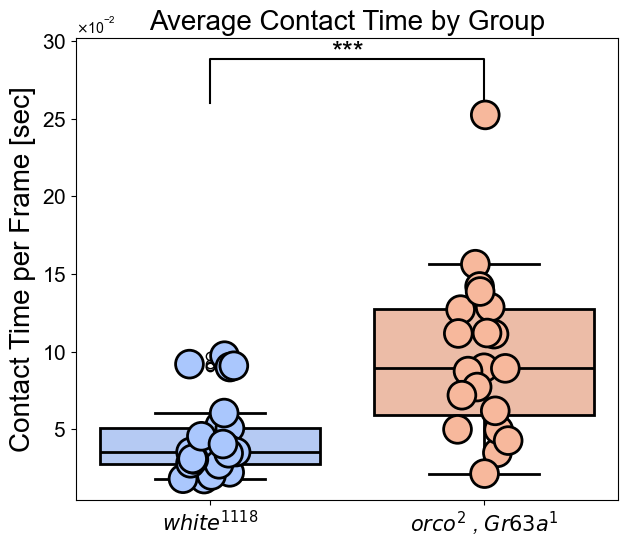

In [223]:
group_contact_rates = contact_time_rate_df.groupby(['Group', 'Matrix_ID','ID1'])['Contact_time_rate'].mean().reset_index()
# コントロール群と変異体群の接触率データ
control_rates = group_contact_rates[group_contact_rates['Group'] == 'control']['Contact_time_rate']
mutant_rates = group_contact_rates[group_contact_rates['Group'] == 'mutant']['Contact_time_rate']
# 正規性の検定
stat_c, p_c = shapiro(control_rates)
stat_m, p_m = shapiro(mutant_rates)
print('Contact_time_rate: Control group normality p-value:', p_c)
print('Contact_time_rate: Mutant group normality p-value:', p_m)
# 分散の等質性の検定
stat_levene, p_levene = levene(control_rates, mutant_rates)
print('Contact_time_rate: Levene test p-value:', p_levene)
if p_c > 0.05 and p_m > 0.05 and p_levene > 0.05:
    # t検定を実施
    stat, p_value = ttest_ind(control_rates, mutant_rates)
    print('Contact_time_rate: t-test p-value:', p_value)
else:
    # マン・ホイットニーのU検定を実施
    stat, p_value = mannwhitneyu(control_rates, mutant_rates, alternative='two-sided')
    print('Contact_time_rate: Mann-Whitney U test p-value:', p_value)


fig, ax = plt.subplots(figsize=(7, 6))
ax.yaxis.set_major_formatter(ptick.ScalarFormatter(useMathText=True))   # こっちを先に書くこと。
ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,-2))

sns.boxplot(x='Group',
            y='Contact_time_rate', 
            data=group_contact_rates,
            linecolor="k",
            linewidth=2,
            palette = 'coolwarm')
sns.stripplot(x='Group', y='Contact_time_rate', data=group_contact_rates, palette="coolwarm", ax=ax,
              edgecolor="k",
            s = 20, linewidth=2)
# フォントサイズやラベルの設定
ax.set_title('Average Contact Time by Group', fontsize=20)
ax.set_xlabel("", fontsize=20)
ax.set_ylabel("Contact Time per Frame [sec]", fontsize=20)
labels = ['$\mathit{white^{1118}}$', '$\mathit{orco^2}$ , $\mathit{Gr63a^1}$']
ax.set_xticklabels(labels, fontsize=15)
ax.tick_params(axis='y', labelsize=15)
labels_get = ax.get_xticklabels()
for lbl in labels_get:
    lbl.set_style('italic')

# 有意差のアノテーション追加
y_max = group_contact_rates['Contact_time_rate'].max()
ymin = group_contact_rates['Contact_time_rate'].min()
h = y_max - ymin
add_stat_annotation(ax, 0, 1, y_max + h / 30, p_value, h / 10 )

In [208]:
contact_time_df = df.groupby(['id1'])['duration'].sum().reset_index()
# 3. カラム名を変更
contact_time_df.rename(columns={
    'id': 'id1',
    'duration': 'Total_Contact_time'
}, inplace=True)

In [222]:
contact_time_rate_df

,Group,Matrix_ID,ID1,ID2,Contact_time_rate
0,control,0,1.0,2.0,0.058000
1,control,0,1.0,3.0,0.088000
2,control,0,1.0,4.0,0.028333
3,control,0,1.0,5.0,0.035667
4,control,0,2.0,1.0,0.110000
...,...,...,...,...,...
152,mutant,3,4.0,5.0,0.244737
153,mutant,3,5.0,1.0,0.134211
154,mutant,3,5.0,2.0,0.044737
155,mutant,3,5.0,3.0,0.106391
